## Lg Q Analysis
Finding event specific source term and Q

In [30]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
import random
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import csv
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm
from scipy.signal import resample
from obspy import Stream
from matplotlib.colors import LogNorm

import pandas as pd

from new_functions import *

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
import warnings
warnings.filterwarnings("ignore")

5.7


In [31]:
existent_catalog_with_coords = []

datacenters = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC','BGR',"http://fdsnws.sismologia.ign.es"]
directory = '/home/schreinl/Stage/Data1/'
distmin = 0.5
distmax = 10.0
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
#catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
eq_list = catalogue_5
codawindow = 'cutoff'
factor = 1.1
fmin = [0.5,2,4]
fmax = [1.5,3,6]
counter = 0
for event in range(len(eq_list)):
    #print("event", event, "out of", len(eq_list))
    start = UTCDateTime(eq_list["time"][event]) - 25
    end = start + 700
    eq_lon = float(eq_list["longitude"][event])
    eq_lat = float(eq_list["latitude"][event])
    
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    existent = True
    for i in range(len(fmin)):
        amplitude_test = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_new_{codawindow}_fac_{factor}_{fmin[i]}_{fmax[i]}Hz_dict.txt"
        if os.path.exists(amplitude_test):
            counter += 1
            if eq_list["time"][event] not in [entry[0] for entry in existent_catalog_with_coords]:
                existent_catalog_with_coords.append((eq_list["time"][event], eq_lat, eq_lon))
        else:
            existent = False

latitudes = [entry[1] for entry in existent_catalog_with_coords]
longitudes = [entry[2] for entry in existent_catalog_with_coords]

event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

for time, lat, lon in existent_catalog_with_coords:
    popup_text = f"Event Time: {time}<br>Lat: {lat}, Lon: {lon}"
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        tooltip=popup_text,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=1
    ).add_to(event_map)


print(f'{len(existent_catalog_with_coords)} events with coordinates found.')
event_map


209 events with coordinates found.


#### Site term calculation

Here all the site terms are calculated, for different frequency bands, and one is plotted.

In [32]:
fmin = 0.5
fmax = 1.5
frequenciesmin = [0.5,2,4,6]
frequenciesmax = [1.5,3,6,8]
event_file='/home/schreinl/Stage/Data/big_box_4.5.csv'
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

#calculate the site terms 
dict_test = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", factor=1.1, fmin=fmin, fmax=fmax, data_dir='Data1',envelope_name='new')
ref_value_test = reference_stations_median(best_bet,event_file, fmin, fmax, envelope_name='new')
sites_effect_dict_test = site_effect_dict(event_file, fmin,fmax,best_bet,envelope_name='new')

site_effects = site_effect_overall(fmin,fmax,best_bet,frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax,method='multiple',map_plot=False,envelope_name='new')
carte = map_site_effect(fmin, fmax, site_effects, method='multiple')
carte.save(f"site_effect_{(fmin+fmax)/2}_Hz_map.html")
carte

done reading in


In [33]:
#get the amplitudes of the Lg waves for all the frequency ranges

'''

from urllib.error import URLError
from http.client import HTTPException
import os
import warnings
warnings.filterwarnings("ignore")

datacenters = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC','BGR',"http://fdsnws.sismologia.ign.es"]
directory = '/home/schreinl/Stage/Data1/'
distmin = 0.5
distmax = 10.0
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
eq_list = catalogue_5
codawindow = 'cutoff'
factor = 1.1
fmin = [0.5,2,4]
fmax = [1.5,3,6]

for event in range(len(eq_list)):
    print("event", event, "out of", len(eq_list))
    start = UTCDateTime(eq_list["time"][event]) -25
    end = start + 700
    eq_lon = float(eq_list["longitude"][event])
    eq_lat = float(eq_list["latitude"][event])
    
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    for i in range(len(fmin)):
        retry_attempts = 3
        
        for attempt in range(retry_attempts):
            try:
                st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
                break
            except (URLError, FDSNNoDataException, HTTPException) as e:
                print(f"Failed to download data for event {event} on attempt {attempt + 1}: {str(e)}")
                if attempt < retry_attempts - 1:
                    print("Retrying with a smaller time window...")
                    end -= 100  # Reduce the time window by 100 seconds and retry
                else:
                    print("Max retry attempts reached. Skipping event...")
                    break  # Exit the retry loop and skip the event




    for i in range(len(fmin)):
        print(f'Frequency range {fmin[i]}-{fmax[i]}')
        
        st_plot_filt_all = st_all.copy()
        st_plot_filt_all.filter("bandpass", freqmin=fmin[i], freqmax=fmax[i])


        snr_threshold = 5
        eq_start = start

        filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_test, filtered_st, stations_with_amps, amp_plot = SNR_all(
            stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min, vLg_max, vPg_min, vPg_max, tminCoda, tmaxCoda,
            Dtmin_Noise, Dtmax_Noise, eq_start, eq_lat, eq_lon, snr_threshold=snr_threshold, plot_SNR=False, plot_amps=True, wavecode="Lg_Coda", dB=True, codawindow=codawindow, factor=factor)

        if filtered_stations_with_SNR is None or len(filtered_stations_with_SNR) == 0:
            continue
        
        with open(f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_{fmin[i]}_{fmax[i]}Hz_{snr_threshold}_thresh_stations_with_amps.txt", "w") as ampls:
            json.dump(stations_with_amps.tolist(), ampls, indent=4)
'''

'\n\nfrom urllib.error import URLError\nfrom http.client import HTTPException\nimport os\nimport warnings\nwarnings.filterwarnings("ignore")\n\ndatacenters = [\'RESIF\', \'ODC\', \'ETH\', \'INGV\', \'GEOFON\', \'IRIS\', \'ICGC\',\'BGR\',"http://fdsnws.sismologia.ign.es"]\ndirectory = \'/home/schreinl/Stage/Data1/\'\ndistmin = 0.5\ndistmax = 10.0\ncatalogue_5 = pd.read_csv(\'/home/schreinl/Stage/Data/big_box_4.5.csv\')\neq_list = catalogue_5\ncodawindow = \'cutoff\'\nfactor = 1.1\nfmin = [0.5,2,4]\nfmax = [1.5,3,6]\n\nfor event in range(len(eq_list)):\n    print("event", event, "out of", len(eq_list))\n    start = UTCDateTime(eq_list["time"][event]) -25\n    end = start + 700\n    eq_lon = float(eq_list["longitude"][event])\n    eq_lat = float(eq_list["latitude"][event])\n    \n    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")\n    for i in range(len(fmin)):\n        retry_attempts = 3\n        \n        for attempt in range(retry_attempts):\n            try:\n  

#### Calculation of the Lg Amplitude of each seismogram for each event

In [34]:




def Lg_amplitude_dict(base_directory):
    events_data = {}

    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)

        if os.path.isdir(dir_path):
            event_stations = {} 
            for filename in os.listdir(dir_path):
                if filename.endswith("_5_thresh_stations_with_amps.txt"):
                    file_path = os.path.join(dir_path, filename)

                    with open(file_path, "r") as f:
                        data = json.load(f)

                    for entry in data:
                        network = entry[0]
                        station_name = entry[1]
                        amplitude = float(entry[12])
                        station_key = f"{network}.{station_name}"
                        event_stations[station_key] = amplitude

            events_data[timestamp_dir] = event_stations

    return events_data

base_directory = "/home/schreinl/Stage/Data1" 
Lg_dict = Lg_amplitude_dict(base_directory)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")






Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [37]:
import os
import json

def Lg_amplitude_dict(base_directory):
    events_data = {}

    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)

        if os.path.isdir(dir_path):
            event_stations = {} 
            for filename in os.listdir(dir_path):
                if filename.endswith("_5_thresh_stations_with_amps.txt"):
                    file_path = os.path.join(dir_path, filename)
                    with open(file_path, "r") as f:
                        data = json.load(f)

                    if isinstance(data, dict):
                        
                        if "stations" in data:
                            data = data["stations"]
                        else:
                            data = []

                    if isinstance(data, list):
                        for entry in data:
                            if isinstance(entry, list) and len(entry) > 12:
                                network = entry[0]
                                station_name = entry[1]
                                amplitude = float(entry[12])
                                station_key = f"{network}.{station_name}"
                                event_stations[station_key] = amplitude

            events_data[timestamp_dir] = event_stations

    return events_data

base_directory = "/home/schreinl/Stage/Data1" 
Lg_dict = Lg_amplitude_dict(base_directory)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")


Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [36]:
#this one correctly reads in the amplitudes for the different frequencies

def Lg_amplitude_dict(base_directory, fmin, fmax):
    events_data = {}
    
    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)
        
        if os.path.isdir(dir_path):
            event_stations = {}
            
            for f1, f2 in zip(fmin, fmax):
                frequency_range = f"{f1}_{f2}Hz" 
                filename = f"{timestamp_dir}_{frequency_range}_5_thresh_stations_with_amps.txt"
                file_path = os.path.join(dir_path, filename)
                
                if os.path.exists(file_path):
                    try:
                        with open(file_path, "r") as f:
                            data = json.load(f)
                        
                        if isinstance(data, list):
                            for entry in data:
                                if isinstance(entry, list) and len(entry) > 12:
                                    network = entry[0]
                                    station_name = entry[1]
                                    amplitude = float(entry[12])
                                    station_key = f"{network}.{station_name}"
                                    
                                    if station_key not in event_stations:
                                        event_stations[station_key] = {}
                                    
                                    event_stations[station_key][frequency_range] = amplitude
                        else:
                            print(f"Unexpected data format in file: {file_path}")
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
            
            if event_stations:
                events_data[timestamp_dir] = event_stations
    
    return events_data

fmin = [0.5, 2, 4, 6]  
fmax = [1.5,3, 6, 8] 

base_directory = "/home/schreinl/Stage/Data1"
Lg_dict = Lg_amplitude_dict(base_directory, fmin, fmax)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")


Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [38]:



# ln(A*r**0.83) - ln(Siteeffect) = ln(Sk) - pi*f*r/Q*V
#f being the center frequency, V the velocity of the Lg wave which can be taken as 3.1km/s
#create a dict that has for each event the amplitude of the Lg wave window for each station 




def Lg_amplitude_calculation(fmin,fmax,Lg_dict,savefile=False):


    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)


    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results = {}
    Q0_calculation_terms = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        #print(formatted_event_time)
        if formatted_event_time not in event_data:
            #print(f"Skipping event {formatted_event_time}: Not found in CSV")
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        event_results = {}
        tmp = {}
        for station, amplitude in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break
            
            if site_effect is None or site_effect <= 0:
                continue 
            #log_value = np.log(amplitude * (r ** 0.83)) - np.log(site_effect)
            log_value = np.log(amplitude) + (5/6)*np.log(r) - np.log(site_effect)
            event_results[station] = {"log_value": log_value, "distance_km": r}
            tmp[station] = {'amplitude': amplitude, 'distance': r, 'site_effect': site_effect}
        results[formatted_event_time] = event_results
        Q0_calculation_terms[formatted_event_time] = tmp

    results_with_coords = {}
    for event_time, event_results in results.items():
        event_lat, event_lon = event_data[event_time]
        results_with_coords[event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "data": event_results
        }
    if savefile:
        with open("../Data1/processed_event_amplitudes.txt", "w") as f:
            json.dump(results, f, indent=4)
        with open("../Data1/orocessed_event_amplitudes_coords.txt", "w") as g:
            json.dump(results_with_coords, g, indent=4)

    print("Processing complete.")
    return results, results_with_coords

In [39]:
base_directory = "/home/schreinl/Stage/Data1" 
#Lg_dict = Lg_amplitude_dict(base_directory,fmin,fmax)
fmin = 0.5
fmax = 1.5
results , results_with_coords= Lg_amplitude_calculation(fmin,fmax,Lg_dict,savefile=True)



Processing complete.


Intercept: -12.021386208680907
Slope: -0.0019073617611328616
for event 2011_09_25T13_17_10 the Q factor is 514.7149975701041


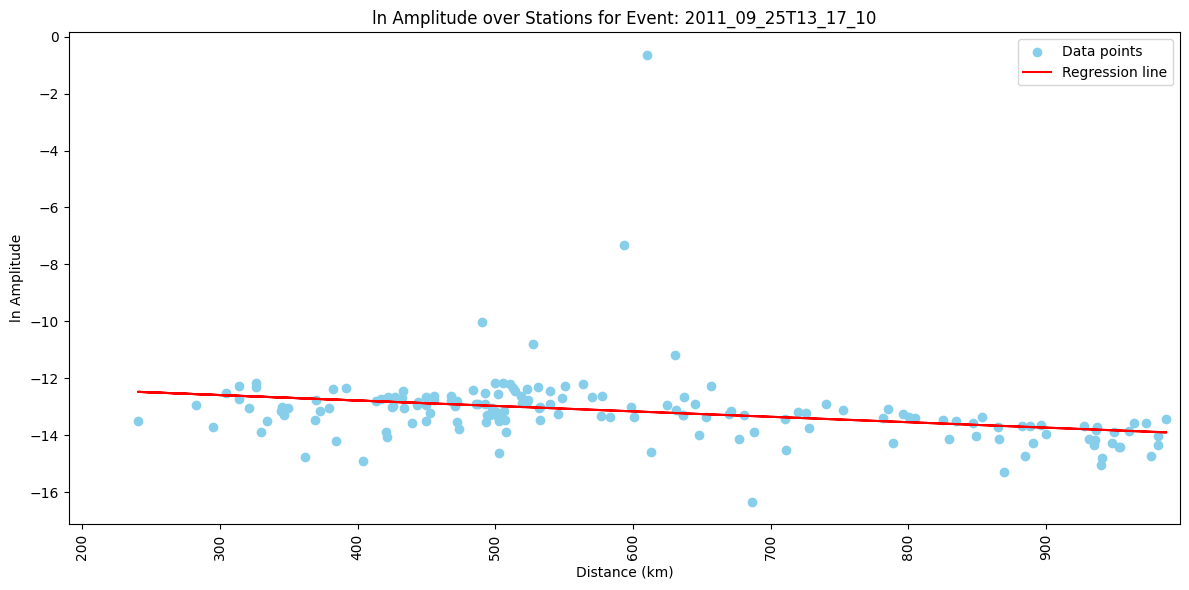

In [40]:
from scipy.stats import linregress
#event_time =  '2023_06_16T16_38_28'#  '2022_11_09T06_07_26'

event_time = list(results.keys())[40] 
event_data = results[event_time]

stations = list(event_data.keys())
log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
distances = [station_data["distance_km"] for station_data in event_data.values()]

filtered_distances = [d for d in distances if d > 200]
filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")
Q = -(np.pi*((fmin+fmax)/2)/(3.2*slope) )
print(f'for event {event_time} the Q factor is {Q}')
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
plt.plot(distances, intercept + slope * np.array(distances), color='red', label='Regression line')
plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190,max(filtered_distances)+10])
plt.title(f'ln Amplitude over Stations for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()




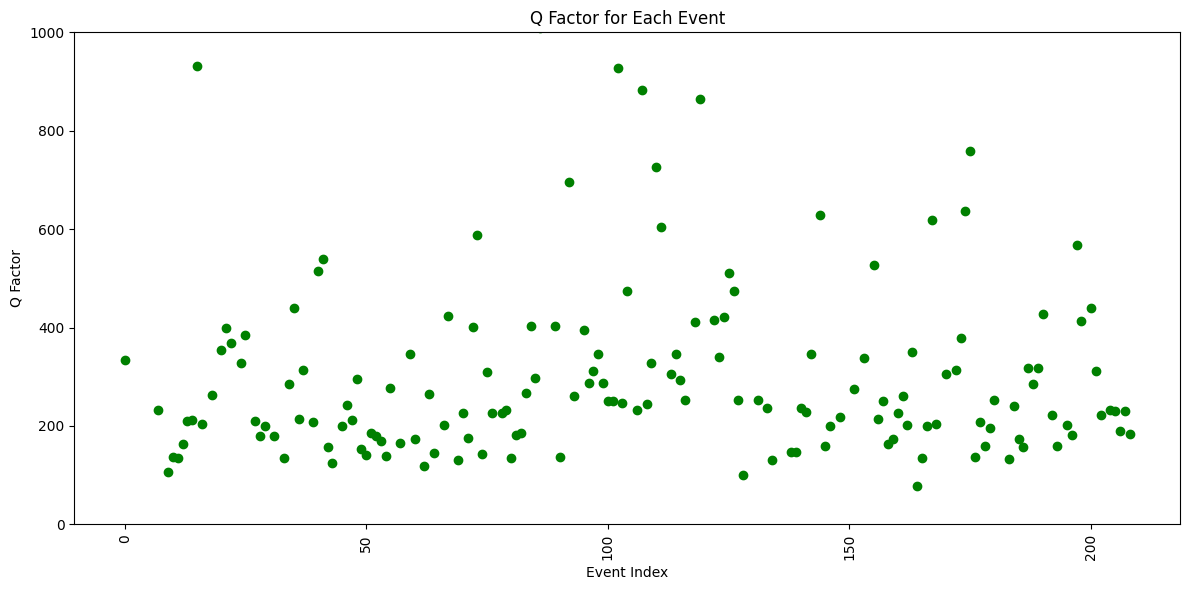

In [73]:


Q_values = {}

for event_time, event_data in results.items():
    stations = list(event_data.keys())
    log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
    distances = [station_data["distance_km"] for station_data in event_data.values()]

    # Filter out distance values less than or equal to 200 km
    filtered_distances = [d for d in distances if d > 200]
    filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

    if len(filtered_distances) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

        Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope))

        Q_values[event_time] = Q
        #this can be sometimes
        #plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
        #plt.plot(filtered_distances, intercept + slope * np.array(filtered_distances), color='red', label='Regression line')
        #plt.xlabel('Distance (km)')
        #plt.ylabel('ln Amplitude')
        #plt.title(f'ln Amplitude over Stations for Event: {event_time}')
        #plt.legend()
        #plt.xticks(rotation=90)
        #plt.tight_layout()
        #plt.show()
plt.figure(figsize=(12, 6))
plt.scatter(range(len(Q_values)), list(Q_values.values()), marker='o', color='green')
plt.xlabel('Event Index')
plt.ylim([0,1000])
plt.ylabel('Q Factor')
plt.title('Q Factor for Each Event')
plt.xticks(range(0, len(Q_values), 50), rotation=90)
plt.tight_layout()
plt.show()

#for event_time, Q in Q_values.items():
#    print(f"Event Time: {event_time}, Q: {Q}")


Processing complete.
Processed 209 events with Q0 and Sk values.


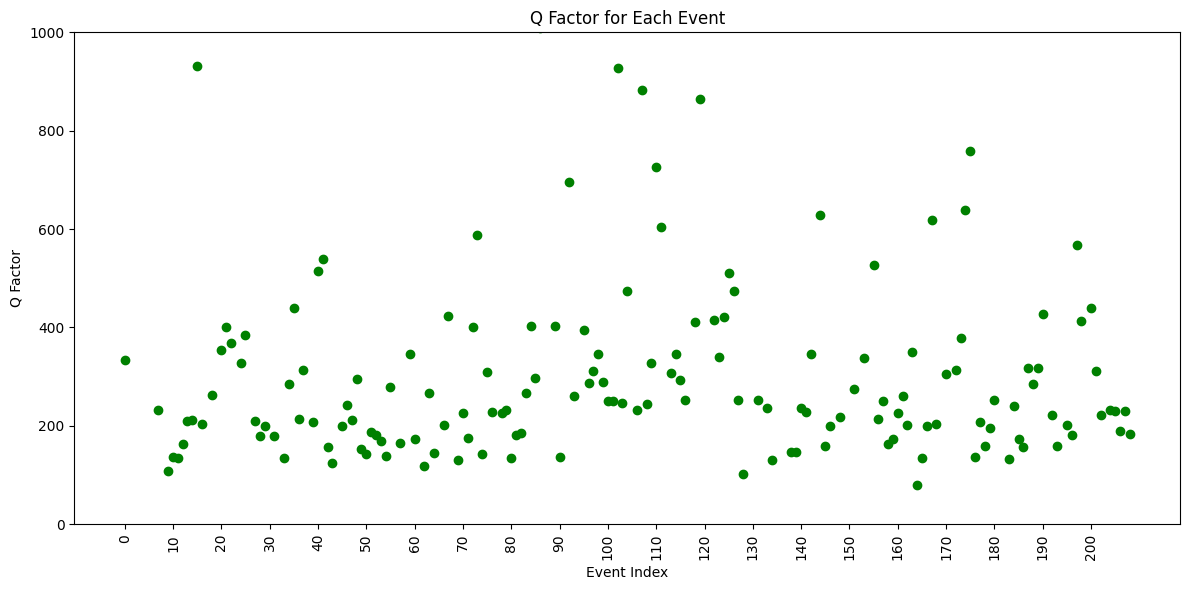

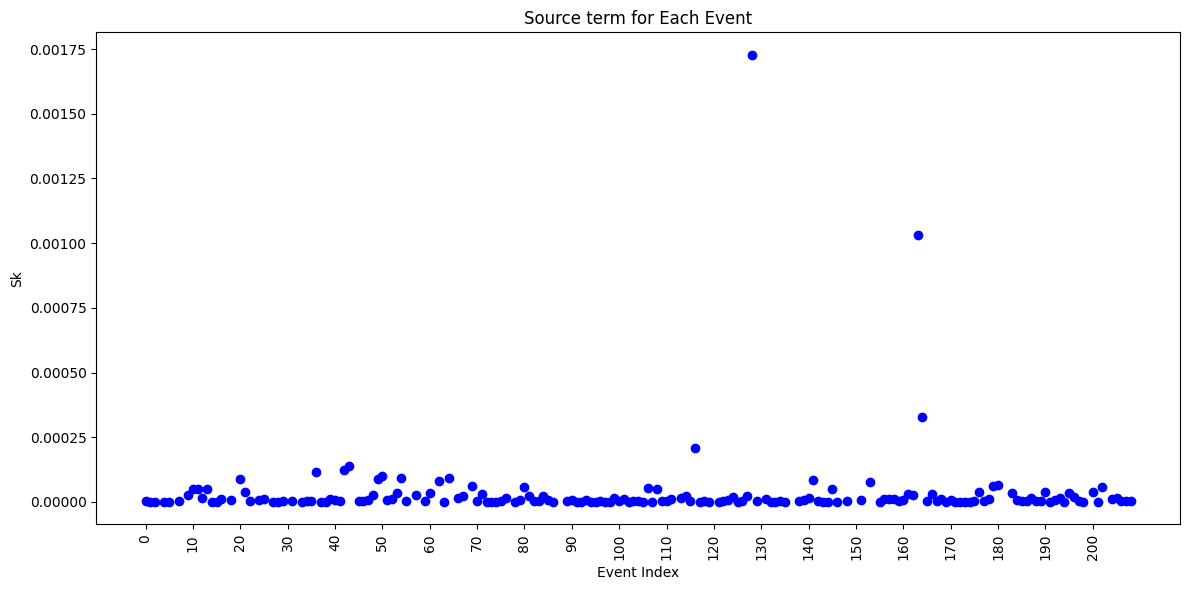

lower boundary -441.14052104776613 and upper boundary 867.4148577204718
177 events on map


In [ ]:
def Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False, plot_Sk_map=False):
    base_directory = "/home/schreinl/Stage/Data1" 
    Lg_dict = Lg_amplitude_dict(base_directory)
    results, results_with_coords = Lg_amplitude_calculation(fmin, fmax, Lg_dict, savefile=False)

    event_data_dict = {}

    for event_time, event_data in results.items():
        log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
        distances = [station_data["distance_km"] for station_data in event_data.values()]

        filtered_distances = [d for d in distances if d > 200]
        filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]
        
        if len(filtered_distances) > 1:
            slope, intercept, _, _, _ = linregress(filtered_distances, filtered_log_amplitudes)
            Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope))
            Sk = np.exp(intercept)
            if event_time in results_with_coords:
                coordinates = results_with_coords[event_time]["coordinates"]
                event_data_dict[event_time] = {
                    "Q0": Q,
                    "Sk": Sk,
                    "coordinates": coordinates
                }

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")

    if plot_Q0 and event_data_dict:
        Q0_values = [data["Q0"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Q0_values)), Q0_values, marker='o', color='green')
        plt.xlabel('Event Index')
        plt.ylim([0, 1000])
        plt.ylabel('Q Factor')
        plt.title('Q Factor for Each Event')
        plt.xticks(range(0, len(Q0_values), max(1, len(Q0_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Sk and event_data_dict:
        Sk_values = [data["Sk"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Sk_values)), Sk_values, marker='o', color='blue')
        plt.xlabel('Event Index')
        plt.ylabel('Sk')
        plt.title('Source term for Each Event')
        plt.xticks(range(0, len(Sk_values), max(1, len(Sk_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Q0_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Q_values = [event_data["Q0"] for event_data in event_data_dict.values()]

        unique_Q_values = sorted(set(Q for Q in Q_values if not np.isnan(Q)))
        print(f'lower boundary {np.percentile(unique_Q_values,5)} and upper boundary {np.percentile(unique_Q_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Q_values,5), 
            vmax=np.percentile(unique_Q_values,95)
        )
        colormap.caption = "Q Factor"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Q = event_data["Q0"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Q):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Q:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Q),  # Use colormap with sorted values
                    weight=1,
                    fill=True,
                    fill_color=colormap(Q),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map
        

    if plot_Sk_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Sk_values = [event_data["Sk"] for event_data in event_data_dict.values()]

        unique_Sk_values = sorted(set(Sk for Sk in Sk_values if np.isfinite(Sk)))
        print(unique_Sk_values)
        print(f'lower boundary {np.percentile(unique_Sk_values,5)} and upper boundary {np.percentile(unique_Sk_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Sk_values,5), 
            vmax=np.percentile(unique_Sk_values,95)
        )
        colormap.caption = "Source Term"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Sk = event_data["Sk"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Sk):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Sk:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Sk),
                    weight=1,
                    fill=True,
                    fill_color=colormap(Sk),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map



    return event_data_dict

Q0_Sk_dict, Q0_map = Lg_Q0_Sk(0.5, 1.5, plot_Q0=True, plot_Sk=True,plot_Q0_map=True)
Q0_map

#fmins = [0.5,2,4,6]
#fmaxs = [1.5,3,6,8]
#Q_mean = {}
#for mini, maxi in zip(fmins,fmaxs):
#    fcenter = (mini+maxi)/2
#    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
#    test_Q0, test_Sk = Lg_Q0_Sk(mini, maxi, plot_Q0=True, plot_Sk=False)
#    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(list(test_Q0.values()))}



In [12]:
first_key = list(Q0_Sk_dict.keys())[0]
print(first_key)
print(Q0_Sk_dict[first_key]['Sk'])

2007_07_18T10_54_11
4.766681757896379e-06


In [56]:
Q0_Sk_dict = Lg_Q0_Sk(2, 3, plot_Q0=False, plot_Sk=False)


latitudes = [event_data['coordinates']["latitude"] for event_data in Q0_Sk_dict.values()]
longitudes = [event_data['coordinates']["longitude"] for event_data in Q0_Sk_dict.values()]
Q_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]

unique_Q_values = sorted(set(Q for Q in Q_values if not np.isnan(Q)))

colormap = cm.LinearColormap(
    colors=["blue", "green", "yellow", "orange", "red"], 
    vmin=80, 
    vmax=550
)
colormap.caption = "Q Factor"

event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

counter = 0
for event_time, event_data in Q0_Sk_dict.items():
    Q = event_data["Q0"]
    lat = event_data['coordinates']["latitude"]
    lon = event_data['coordinates']["longitude"]
    
    if not np.isnan(Q):
        counter += 1
        popup_text = f"Event: {event_time}<br>Q: {Q:.2f}"
        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            tooltip=popup_text,
            color=colormap(Q),  # Use colormap with sorted values
            weight=1,
            fill=True,
            fill_color=colormap(Q),
            fill_opacity=0.9
        ).add_to(event_map)

colormap.add_to(event_map)
print(f'{counter} events on map')
event_map


Processing complete.
Processed 209 events with Q0 and Sk values.
179 events on map


### Frequency dependency of Q



We measure the attenuation factor Q as well as the source term for each event, based on the natural logarithm of the amplitudes of the Lg wave corrected by the geometry factor as well as the site term. 
This corrected amplitude is then plotted over the event-station distance, and a linear regression is done to find the parameters of the distribution. The intercept in this case corresponds to the source term while the slope corresponds to the attenuation factor Q.

frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processed 209 events with Q0 and Sk values.
Coefficients: a = 158.21871549787284, b = 1.362412075874514


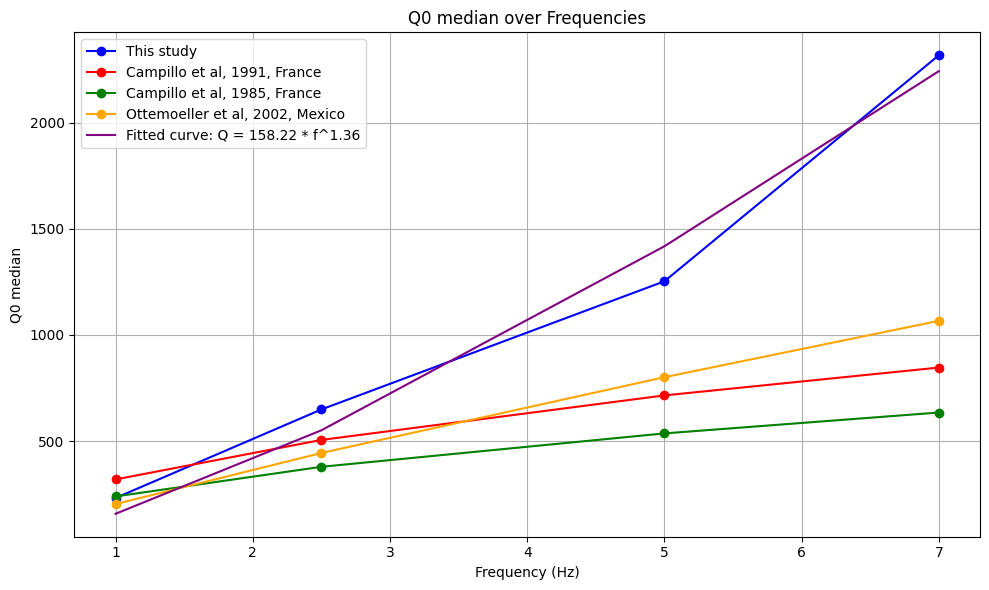

In [57]:
from scipy.optimize import curve_fit

def power_law(frequency, a, b):
    return a * frequency**b




fmins = [0.5, 2, 4,6]
fmaxs = [1.5, 3, 6,8]
Q_mean = {}
for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    Q0_Sk_dict = Lg_Q0_Sk(mini, maxi, plot_Q0=False, plot_Sk=False)
    Q0_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]
    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q_mean"] for data in Q_mean.values()]




frequencies = np.array([float(freq.split()[0]) for freq in Q_mean.keys()])
campillo_1991 = 320 * frequencies ** 0.5
campillo_1985 = 240 * frequencies ** 0.5
ottemoeller_2002 = 204* frequencies ** 0.85


popt, pcov = curve_fit(power_law, frequencies, Q_mean_values)

a, b = popt
print(f"Coefficients: a = {a}, b = {b}")

fitted_Q = power_law(frequencies, a, b)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, Q_mean_values, marker='o', linestyle='-', color='blue', label='This study')
plt.plot(frequencies, campillo_1991, marker='o', linestyle='-', color='red', label='Campillo et al, 1991, France')
plt.plot(frequencies, campillo_1985, marker='o', linestyle='-', color='green', label='Campillo et al, 1985, France')
plt.plot(frequencies, ottemoeller_2002, marker='o', linestyle='-', color='orange', label='Ottemoeller et al, 2002, Mexico')
plt.plot(frequencies, fitted_Q, '-', label=f'Fitted curve: Q = {a:.2f} * f^{b:.2f}', color='purple')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q0 median')
plt.title('Q0 median over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Finding path specific Q

$$ \ln(A_{k,l} \cdot r^{0.83}) - \ln(P(f)) = \ln(S_k) - \frac{\pi \cdot f \cdot r}{Q \cdot V} $$
which has to be rewritten to find $$ Q_{k,l} $$, which is possible due to all the other terms being known. 

In [103]:
def Lg_Q_kl(fmin, fmax, Lg_dict, savefile=False):
    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)
    
    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))
    
    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)
    
    Q0_Sk_dict = Lg_Q0_Sk(fmin, fmax)
    Qkl_dict = {}
    v = 3.2
    
    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        Qkl_dict[formatted_event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "stations": {}
        }
        
        for station, amplitude in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)
            
            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break
            
            if site_effect is None or site_effect <= 0 or r == 0:
                continue
            
            f = (fmin + fmax) / 2 

            source_term = Q0_Sk_dict[formatted_event_time]['Sk']            
            Qkl = (-(np.pi * r * f) / v) * (-np.log(site_effect) - np.log(source_term) + np.log(amplitude * r**0.83))**-1
            
            Qkl_dict[formatted_event_time]["stations"][station] = {
                "Qkl": Qkl,
                "coordinates": {"latitude": lat, "longitude": lon}
            }
    
    if savefile:
        with open("../Data1/Qkl_results.json", "w") as f:
            json.dump(Qkl_dict, f, indent=4)
    
    return Qkl_dict

test_Qkl = Lg_Q_kl(0.5, 1.5, Lg_dict)

Processing complete.
Processed 203 events with Q0 and Sk values.


TypeError: unsupported operand type(s) for *: 'dict' and 'float'

In [16]:
first_key = list(test_Qkl.keys())[0]
print(first_key)
print(test_Qkl[first_key])

2007_07_18T10_54_11
{'coordinates': {'latitude': 43.741, 'longitude': 15.174}, 'stations': {'FR.ANTF': {'Qkl': 136.6877691635848, 'coordinates': {'latitude': 43.5644, 'longitude': 7.1234}}, 'FR.CALF': {'Qkl': 242.01522226583648, 'coordinates': {'latitude': 43.7528, 'longitude': 6.9218}}, 'FR.ESCA': {'Qkl': 298.84534338633364, 'coordinates': {'latitude': 43.831, 'longitude': 7.3744}}, 'FR.OGAG': {'Qkl': 247.6585365225718, 'coordinates': {'latitude': 44.78784, 'longitude': 6.539745}}, 'FR.OGDI': {'Qkl': 221.75301283573833, 'coordinates': {'latitude': 44.1093, 'longitude': 6.2253}}, 'FR.SAOF': {'Qkl': 215.55172127416355, 'coordinates': {'latitude': 43.986, 'longitude': 7.5532}}, 'OE.ARSA': {'Qkl': 174.48420238110708, 'coordinates': {'latitude': 47.2505, 'longitude': 15.5232}}, 'OE.DAVA': {'Qkl': 249.1710618815513, 'coordinates': {'latitude': 47.286701, 'longitude': 9.8803}}, 'OE.KBA': {'Qkl': 213.77339934239086, 'coordinates': {'latitude': 47.0784, 'longitude': 13.3447}}, 'OE.MOA': {'Qkl'

### Plotting on a map as connecting event-station lines the Qkl


Relatively useless, since the lines are all over the place.

In [ ]:
'''
def plot_Qkl_map(Qkl_dict, fmin, fmax):
    Qkl_values = []
    for event in Qkl_dict.values():
        if 'stations' in event: 
            for station, station_data in event['stations'].items():
                Qkl = station_data.get('Qkl', None)
                if Qkl is not None and np.isfinite(Qkl):  # Filter out None and NaN values
                    Qkl_values.append(Qkl)

    if not Qkl_values:
        raise ValueError("No valid Qkl values found for plotting.")

    Qkl_values.sort()

    vmin = np.percentile(Qkl_values, 5)
    vmax = np.percentile(Qkl_values, 95)
    if vmin > vmax:
        vmin, vmax = sorted([vmin, vmax])

    colormap = LinearColormap(
        colors=["blue", "green", "yellow", "orange", "red"],
        vmin=vmin,
        vmax=vmax
    )

    latitudes = []
    longitudes = []

    for event in Qkl_dict.values():
        if 'coordinates' in event:
            event_lat = event['coordinates'].get('latitude')
            event_lon = event['coordinates'].get('longitude')
            if event_lat is not None and event_lon is not None:
                latitudes.append(event_lat)
                longitudes.append(event_lon)

        for station, station_data in event.get('stations', {}).items():
            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')
            if station_lat is not None and station_lon is not None:
                latitudes.append(station_lat)
                longitudes.append(station_lon)

    event_map = folium.Map(
        location=[np.mean(latitudes), np.mean(longitudes)],
        zoom_start=5,
        tiles="OpenStreetMap",
    )

    for event_time, event in Qkl_dict.items():
        if 'coordinates' not in event:
            continue
        event_lat = event['coordinates'].get('latitude')
        event_lon = event['coordinates'].get('longitude')

        if event_lat is None or event_lon is None:
            continue

        for station, station_data in event.get('stations', {}).items():
            Qkl = station_data.get('Qkl', None)
            if Qkl is None or not np.isfinite(Qkl):  # Skip invalid Qkl values
                continue

            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')

            folium.PolyLine(
                locations=[(event_lat, event_lon), (station_lat, station_lon)],
                color=colormap(Qkl), 
                weight=2,
                opacity=0.5,  # Set transparency
                tooltip=f"Event: {event_time}<br>Station: {station}<br>Qkl: {Qkl:.2f}"
            ).add_to(event_map)

    colormap.add_to(event_map)

    return event_map

Qkl_map = plot_Qkl_map(test_Qkl, fmin=0.5, fmax=1.5)
Qkl_map
'''

NameError: name 'LinearColormap' is not defined

### Testing the sensitivity of Q0 towards the Site term

Artificially modifying the site term to find how errors in the site term influence the measurements of Q.

In [26]:
def Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_term_bias=0.0):
    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)

    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results_real = {}
    results_biased = {}
    results_no_site_term = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue

        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue

        event_lat, event_lon = event_data[formatted_event_time]
        event_results_real = {}
        event_results_biased = {}
        event_results_no_site_term = {}

        for station, amplitude in stations.items():
            if station not in station_coords:
                continue

            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break

            if site_effect is None or site_effect <= 0:
                continue

            # Real site term calculation
            log_value_real = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(site_effect)
            event_results_real[station] = {"log_value": log_value_real, "distance_km": r}

            # Biased site term calculation
            biased_site_effect = site_effect + site_term_bias
            log_value_biased = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(biased_site_effect)
            event_results_biased[station] = {"log_value": log_value_biased, "distance_km": r}

            # No site term calculation
            log_value_no_site_term = np.log(amplitude) + (5 / 6) * np.log(r)
            event_results_no_site_term[station] = {"log_value": log_value_no_site_term, "distance_km": r}

        results_real[formatted_event_time] = event_results_real
        results_biased[formatted_event_time] = event_results_biased
        results_no_site_term[formatted_event_time] = event_results_no_site_term

    print("Processing complete.")
    return results_real, results_biased, results_no_site_term

results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(fmin=0.5, fmax=1.5, Lg_dict=Lg_dict, site_term_bias=5)


TypeError: loop of ufunc does not support argument 0 of type dict which has no callable log method

Real values for event 2011_09_25T13_17_10:
Intercept: -12.021386208680909
Slope: -0.0019073617611328612
Q factor: 514.7149975701042
Biased values for event 2011_09_25T13_17_10:
Intercept: -13.349850683965526
Slope: -0.002531470491731632
Q factor: 387.8171629704653
No site term values for event 2011_09_25T13_17_10:
Intercept: -11.387065697385767
Slope: -0.0027113066781188607
Q factor: 362.0939350645348


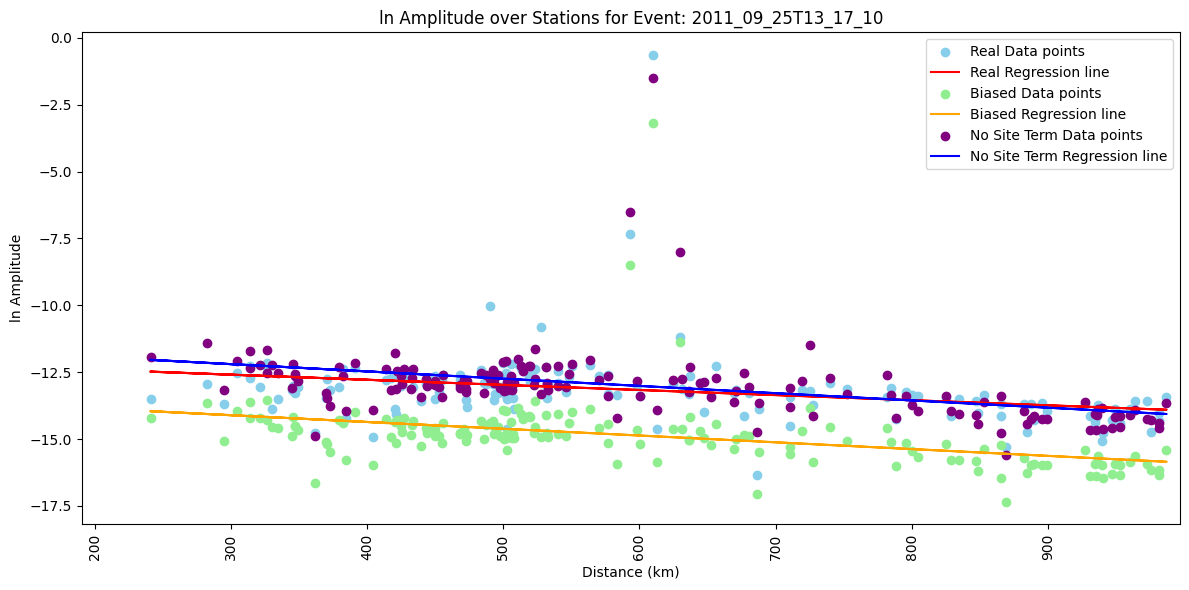

In [60]:
event_time = list(results_real.keys())[40] 
event_data_real = results_real[event_time]
event_data_biased = results_biased[event_time]
event_data_no_site_term = results_no_site_term[event_time]

# Real values
stations_real = list(event_data_real.keys())
log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]

filtered_distances_real = [d for d in distances_real if d > 200]
filtered_log_amplitudes_real = [log_amplitudes_real[i] for i in range(len(distances_real)) if distances_real[i] > 200]

slope_real, intercept_real, _, _, _ = linregress(filtered_distances_real, filtered_log_amplitudes_real)

Q_real = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_real))
print(f"Real values for event {event_time}:")
print(f"Intercept: {intercept_real}")
print(f"Slope: {slope_real}")
print(f"Q factor: {Q_real}")

# Biased values
stations_biased = list(event_data_biased.keys())
log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]

filtered_distances_biased = [d for d in distances_biased if d > 200]
filtered_log_amplitudes_biased = [log_amplitudes_biased[i] for i in range(len(distances_biased)) if distances_biased[i] > 200]

slope_biased, intercept_biased, _, _, _ = linregress(filtered_distances_biased, filtered_log_amplitudes_biased)

Q_biased = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_biased))
print(f"Biased values for event {event_time}:")
print(f"Intercept: {intercept_biased}")
print(f"Slope: {slope_biased}")
print(f"Q factor: {Q_biased}")

# No site term values
stations_no_site_term = list(event_data_no_site_term.keys())
log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]

filtered_distances_no_site_term = [d for d in distances_no_site_term if d > 200]
filtered_log_amplitudes_no_site_term = [log_amplitudes_no_site_term[i] for i in range(len(distances_no_site_term)) if distances_no_site_term[i] > 200]

slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)

Q_no_site_term = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_no_site_term))
print(f"No site term values for event {event_time}:")
print(f"Intercept: {intercept_no_site_term}")
print(f"Slope: {slope_no_site_term}")
print(f"Q factor: {Q_no_site_term}")

# Combined plot
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances_real, filtered_log_amplitudes_real, color='skyblue', label='Real Data points')
plt.plot(filtered_distances_real, intercept_real + slope_real * np.array(filtered_distances_real), color='red', label='Real Regression line')

plt.scatter(filtered_distances_biased, filtered_log_amplitudes_biased, color='lightgreen', label='Biased Data points')
plt.plot(filtered_distances_biased, intercept_biased + slope_biased * np.array(filtered_distances_biased), color='orange', label='Biased Regression line')

plt.scatter(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term, color='purple', label='No Site Term Data points')
plt.plot(filtered_distances_no_site_term, intercept_no_site_term + slope_no_site_term * np.array(filtered_distances_no_site_term), color='blue', label='No Site Term Regression line')

plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190, max(max(filtered_distances_real), max(filtered_distances_biased), max(filtered_distances_no_site_term)) + 10])
plt.title(f'ln Amplitude over Stations for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Processing complete.
Processed 209 events with Q0 and Sk values.


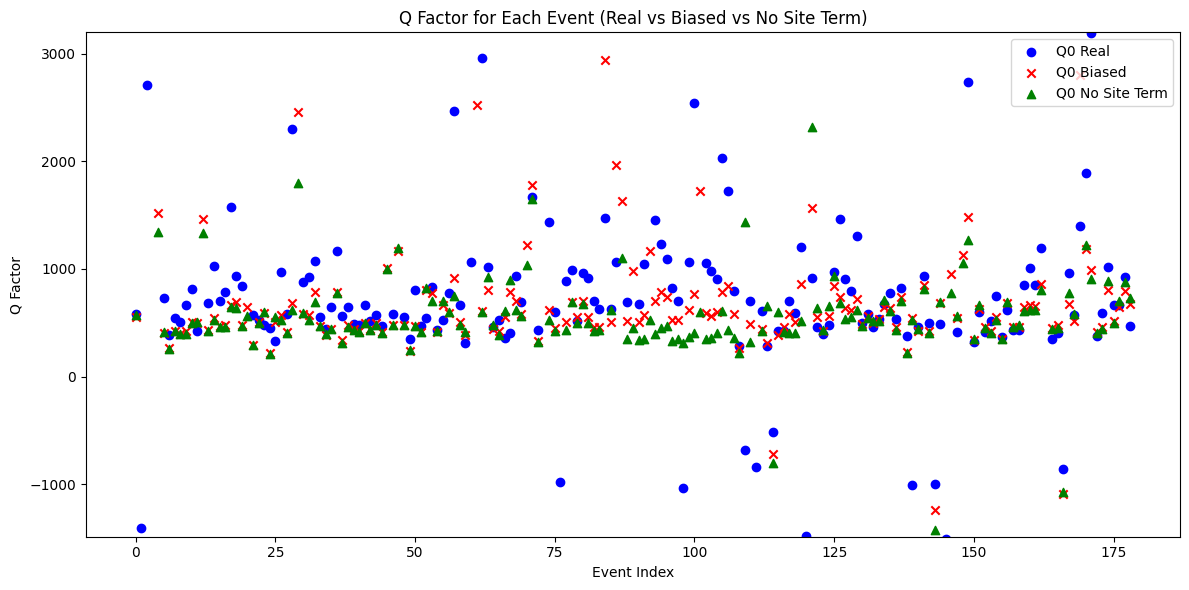

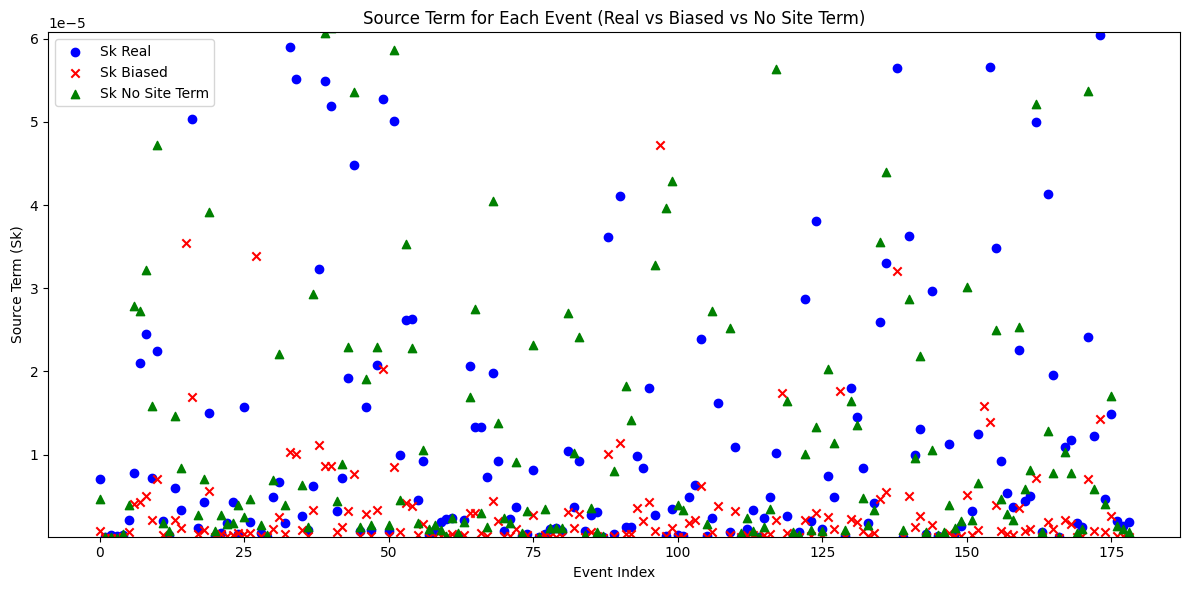

Average difference between Q0 real and Q0 biased: 1868.6201751225133
Average difference between Q0 real and Q0 no site term: 1743.509994154112


In [61]:
def Lg_Q0_Sk_biased(fmin, fmax, site_term_bias=0.1, plot_Q0=False, plot_Sk=False):
    base_directory = "/home/schreinl/Stage/Data1" 
    Lg_dict = Lg_amplitude_dict(base_directory)
    results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_term_bias=site_term_bias)

    event_data_dict = {}
    square_vals = {"Q0 real - Q0 bias": {},"Q0 real - Q0 no site term": {}, "Sk real - Sk bias": {}, "Sk real - Sk no site term": {}}
    l2_norms = {}

    for event_time, event_data_real in results_real.items():
        event_data_biased = results_biased.get(event_time, {})
        event_data_no_site_term = results_no_site_term.get(event_time, {})
        
        # Extract real data
        log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
        distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]
        filtered_distances_real = [d for d in distances_real if d > 200]
        filtered_log_amplitudes_real = [log_amplitudes_real[i] for i in range(len(distances_real)) if distances_real[i] > 200]

        # Extract biased data
        log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
        distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]
        filtered_distances_biased = [d for d in distances_biased if d > 200]
        filtered_log_amplitudes_biased = [log_amplitudes_biased[i] for i in range(len(distances_biased)) if distances_biased[i] > 200]

        # Extract no site term data
        log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
        distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]
        filtered_distances_no_site_term = [d for d in distances_no_site_term if d > 200]
        filtered_log_amplitudes_no_site_term = [log_amplitudes_no_site_term[i] for i in range(len(distances_no_site_term)) if distances_no_site_term[i] > 200]

        if len(filtered_distances_real) > 1 and len(filtered_distances_biased) > 1 and len(filtered_distances_no_site_term) > 1:
            # Real data regression
            slope_real, intercept_real, _, _, _ = linregress(filtered_distances_real, filtered_log_amplitudes_real)
            if isinstance(slope_real, (int, float)) and slope_real != 0:
                Q_real = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_real))
                Sk_real = np.exp(intercept_real)
            else:
                Q_real = None
                Sk_real = None

            # Biased data regression
            if len(filtered_distances_biased) > 1:
                slope_biased, intercept_biased, _, _, _ = linregress(filtered_distances_biased, filtered_log_amplitudes_biased)
                if isinstance(slope_biased, (int, float)) and slope_biased != 0:
                    Q_biased = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_biased))
                    Sk_biased = np.exp(intercept_biased)
                else:
                    Q_biased = None
                    Sk_biased = None
            else:
                Q_biased = None
                Sk_biased = None

            # No site term data regression
            slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)
            Q_no_site_term = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_no_site_term))
            Sk_no_site_term = np.exp(intercept_no_site_term)

            if event_time in results_with_coords:
                coordinates = results_with_coords[event_time]["coordinates"]
                event_data_dict[event_time] = {
                    "Q0_real": Q_real,
                    "Sk_real": Sk_real,
                    "Q0_biased": Q_biased,
                    "Sk_biased": Sk_biased,
                    "Q0_no_site_term": Q_no_site_term,
                    "Sk_no_site_term": Sk_no_site_term,
                    "coordinates": coordinates
                }

                if Q_real is not None and Q_biased is not None:
                    square_vals["Q0 real - Q0 bias"][event_time] = (Q_real - Q_biased) ** 2
                    
                if Q_real is not None and Q_no_site_term is not None:
                    square_vals["Q0 real - Q0 no site term"][event_time] = (Q_real - Q_no_site_term) ** 2 
                    
                if Sk_real is not None and Sk_biased is not None:
                    square_vals["Sk real - Sk bias"][event_time] = (Sk_real - Sk_biased) ** 2
                    
                if Sk_real is not None and Sk_no_site_term is not None:
                    square_vals["Sk real - Sk no site term"][event_time] = (Sk_real - Sk_no_site_term) ** 2 
                    

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")
    for norm_key, norm_values in l2_norms.items():
        valid_norms = [v for v in norm_values.values() if np.isfinite(v)]
        if valid_norms:
            print(f"L2 Norms for {norm_key}: {valid_norms}")
        else:
            print(f"L2 Norms for {norm_key}: No valid values.")
    
    for key, values in square_vals.items():
        valid_values = [v for v in values.values() if np.isfinite(v)]
        if valid_values:
            l2_norms[key] = np.sqrt(np.sum(valid_values))
        else:
            l2_norms[key] = None



    if plot_Q0 and event_data_dict:
        Q0_real_values = [data["Q0_real"] for data in event_data_dict.values() if np.isfinite(data["Q0_real"])]
        Q0_biased_values = [data["Q0_biased"] for data in event_data_dict.values() if np.isfinite(data["Q0_biased"])]
        Q0_no_site_term_values = [data["Q0_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Q0_no_site_term"])]
        
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Q0_real_values)), Q0_real_values, marker='o', color='blue', label='Q0 Real')
            plt.scatter(range(len(Q0_biased_values)), Q0_biased_values, marker='x', color='red', label='Q0 Biased')
            plt.scatter(range(len(Q0_no_site_term_values)), Q0_no_site_term_values, marker='^', color='green', label='Q0 No Site Term')
            plt.xlabel('Event Index')
            plt.ylim([np.percentile(Q0_real_values, 5), np.percentile(Q0_real_values, 95)])
            plt.ylabel('Q Factor')
            plt.title('Q Factor for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

    if plot_Sk and event_data_dict:
        Sk_real_values = [data["Sk_real"] for data in event_data_dict.values() if np.isfinite(data["Sk_real"])]
        Sk_biased_values = [data["Sk_biased"] for data in event_data_dict.values() if np.isfinite(data["Sk_biased"])]
        Sk_no_site_term_values = [data["Sk_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Sk_no_site_term"])]
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Sk_real_values)), Sk_real_values, marker='o', color='blue', label='Sk Real')
            plt.scatter(range(len(Sk_biased_values)), Sk_biased_values, marker='x', color='red', label='Sk Biased')
            plt.scatter(range(len(Sk_no_site_term_values)), Sk_no_site_term_values, marker='^', color='green', label='Sk No Site Term')
            plt.xlabel('Event Index')
            plt.ylim([np.percentile(Sk_real_values, 5), np.percentile(Sk_real_values, 95)])
            plt.ylabel('Source Term (Sk)')
            plt.title('Source Term for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

        q0_real_q0_biased_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 bias"].values() if np.isfinite(v)]
        average_diff_real_biased = np.mean(q0_real_q0_biased_diffs) if q0_real_q0_biased_diffs else None

        q0_real_q0_no_site_term_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 no site term"].values() if np.isfinite(v)]
        average_diff_real_no_site_term = np.mean(q0_real_q0_no_site_term_diffs) if q0_real_q0_no_site_term_diffs else None

        print(f"Average difference between Q0 real and Q0 biased: {average_diff_real_biased}")
        print(f"Average difference between Q0 real and Q0 no site term: {average_diff_real_no_site_term}")


    return event_data_dict, l2_norms


biased_dict, l2_norms = Lg_Q0_Sk_biased(2, 3, site_term_bias=5, plot_Q0=True, plot_Sk=True)

frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processed 209 events with Q0 and Sk values.


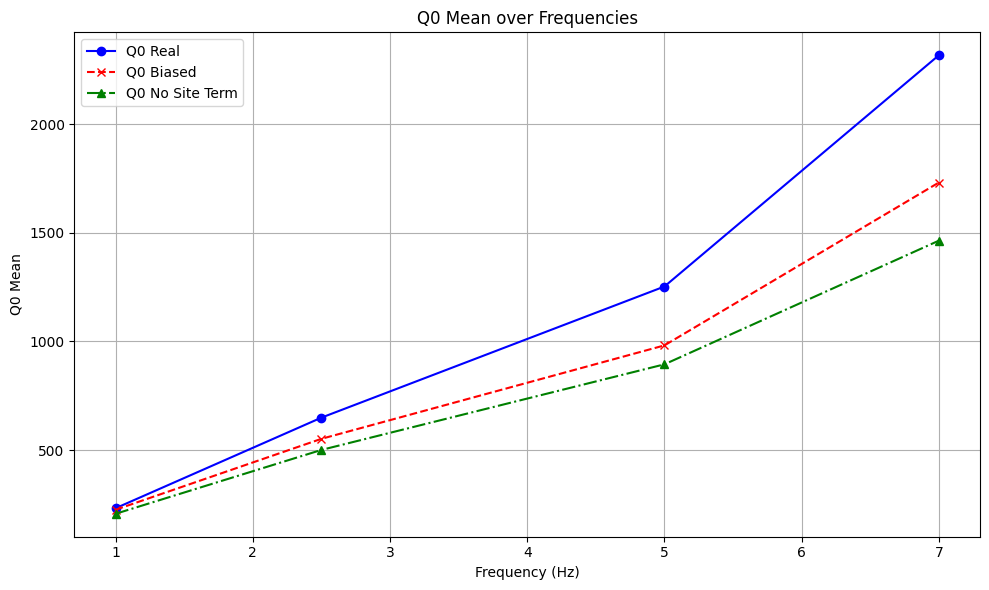

In [62]:
fmins = [0.5, 2, 4,6]
fmaxs = [1.5, 3, 6, 8]
Q_mean = {}
for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    biased_dict, l2_norms = Lg_Q0_Sk_biased(mini, maxi, site_term_bias=5)
    Q0_real_values = [data["Q0_real"] for data in biased_dict.values() if np.isfinite(data["Q0_real"])]
    Q0_biased_values = [data["Q0_biased"] for data in biased_dict.values() if np.isfinite(data["Q0_biased"])]
    Q0_no_site_term_values = [data["Q0_no_site_term"] for data in biased_dict.values() if np.isfinite(data["Q0_no_site_term"])]
    Q_mean[f'{fcenter} Hz'] = {"Q0_real": np.nanmedian(Q0_real_values), "Q0_biased": np.nanmedian(Q0_biased_values), "Q0_no_ite_term": np.nanmedian(Q0_no_site_term_values)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q0_real"] for data in Q_mean.values()]




frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q0_real_values = [data["Q0_real"] for data in Q_mean.values()]
Q0_biased_values = [data["Q0_biased"] for data in Q_mean.values()]
Q0_no_site_term_values = [data["Q0_no_ite_term"] for data in Q_mean.values()]

plt.figure(figsize=(10, 6))
plt.plot(frequencies, Q0_real_values, marker='o', linestyle='-', color='blue', label='Q0 Real')
plt.plot(frequencies, Q0_biased_values, marker='x', linestyle='--', color='red', label='Q0 Biased')
plt.plot(frequencies, Q0_no_site_term_values, marker='^', linestyle='-.', color='green', label='Q0 No Site Term')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q0 Mean')
plt.title('Q0 Mean over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
def Lg_Q0_Sk_biased(fmin, fmax, site_term_bias=0.1, plot_Q0=False, plot_Sk=False):
    base_directory = "/home/schreinl/Stage/Data1"
    Lg_dict = Lg_amplitude_dict(base_directory)
    results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_term_bias=site_term_bias)

    event_data_dict = {}
    l2_norms = {"Q0 real - Q0 bias": {}, "Q0 real - Q0 no site term": {}, "Sk real - Sk bias": {}, "Sk real - Sk no site term": {}}

    for event_time, event_data_real in results_real.items():
        event_data_biased = results_biased.get(event_time, {})
        event_data_no_site_term = results_no_site_term.get(event_time, {})
        
        def extract_filtered_data(event_data):
            log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
            distances = [station_data["distance_km"] for station_data in event_data.values()]
            return [d for d in distances if d > 200], [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

        filtered_distances_real, filtered_log_amplitudes_real = extract_filtered_data(event_data_real)
        filtered_distances_biased, filtered_log_amplitudes_biased = extract_filtered_data(event_data_biased)
        filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term = extract_filtered_data(event_data_no_site_term)

        if len(filtered_distances_real) > 1 and len(filtered_distances_biased) > 1 and len(filtered_distances_no_site_term) > 1:
            def compute_regression(distances, log_amplitudes):
                if len(distances) > 1:
                    slope, intercept, _, _, _ = linregress(distances, log_amplitudes)
                    Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope)) if slope not in [None, 0] else None
                    Sk = np.exp(intercept) if intercept is not None else None
                    return Q, Sk
                return None, None

            Q_real, Sk_real = compute_regression(filtered_distances_real, filtered_log_amplitudes_real)
            Q_biased, Sk_biased = compute_regression(filtered_distances_biased, filtered_log_amplitudes_biased)
            Q_no_site_term, Sk_no_site_term = compute_regression(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)

            if event_time in results_with_coords:
                event_data_dict[event_time] = {
                    "Q0_real": Q_real, "Sk_real": Sk_real,
                    "Q0_biased": Q_biased, "Sk_biased": Sk_biased,
                    "Q0_no_site_term": Q_no_site_term, "Sk_no_site_term": Sk_no_site_term,
                    "coordinates": results_with_coords[event_time]["coordinates"]
                }

                if Q_real is not None and Q_biased is not None:
                    l2_norms["Q0 real - Q0 bias"][event_time] = (Q_real - Q_biased) ** 2
                if Q_real is not None and Q_no_site_term is not None:
                    l2_norms["Q0 real - Q0 no site term"][event_time] = (Q_real - Q_no_site_term) ** 2
                if Sk_real is not None and Sk_biased is not None:
                    l2_norms["Sk real - Sk bias"][event_time] = (Sk_real - Sk_biased) ** 2
                if Sk_real is not None and Sk_no_site_term is not None:
                    l2_norms["Sk real - Sk no site term"][event_time] = (Sk_real - Sk_no_site_term) ** 2

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")
    for norm_key, norm_values in l2_norms.items():
        valid_norms = [v for v in norm_values.values() if np.isfinite(v)]
        if valid_norms:
            print(f"L2 Norms for {norm_key}: {np.sqrt(np.sum(valid_norms))}")
        else:
            print(f"L2 Norms for {norm_key}: No valid values.")
    
    return event_data_dict, l2_norms

biased_dict, l2_norms = Lg_Q0_Sk_biased(0.5, 1.5, site_term_bias=5, plot_Q0=True, plot_Sk=True)


Processing complete.
Processed 209 events with Q0 and Sk values.
L2 Norms for Q0 real - Q0 bias: 40918.88540227615
L2 Norms for Q0 real - Q0 no site term: 40727.42504900391
L2 Norms for Sk real - Sk bias: 0.0015318538812514903
L2 Norms for Sk real - Sk no site term: 0.022017924086865443


### Correct frequency handling 
before i believe wrong amplitudes have been used, so here is the workflow with adapted functions

In [104]:

#this one correctly reads in the amplitudes for the different frequencies

def Lg_amplitude_dict(base_directory, fmin, fmax):
    '''
    Input:
    - base_directory: str, the directory where the files are stored, mostly "/home/schreinl/Stage/Data1"
    - fmin: list of float, the minimum frequency
    - fmax: list of float, the maximum frequency

    Output:
    - Lg_dict: dict, where the keys are the event names and the values are dictionaries with station names as keys
               and the frequency bands and their amplitudes as values.
    This function reads in the Lg amplitude from all available events, and stores in a dict, where for all events the amplitude
    of all station is stored, if existent, for all the frequency ranges.
    
    Can be combined with: output_path = "..."
    with open(output_path, "w") as f:
        json.dump(Lg_dict, f, indent=4), in order to store the output file.


    '''
    events_data = {}
    
    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)
        
        if os.path.isdir(dir_path):
            event_stations = {}
            
            for f1, f2 in zip(fmin, fmax):
                frequency_range = f"{f1}_{f2}Hz" 
                filename = f"{timestamp_dir}_{frequency_range}_5_thresh_stations_with_amps.txt"
                file_path = os.path.join(dir_path, filename)
                
                if os.path.exists(file_path):
                    try:
                        with open(file_path, "r") as f:
                            data = json.load(f)
                        
                        if isinstance(data, list):
                            for entry in data:
                                if isinstance(entry, list) and len(entry) > 12:
                                    network = entry[0]
                                    station_name = entry[1]
                                    amplitude = float(entry[12])
                                    station_key = f"{network}.{station_name}"
                                    
                                    if station_key not in event_stations:
                                        event_stations[station_key] = {}
                                    
                                    event_stations[station_key][frequency_range] = amplitude
                        else:
                            print(f"Unexpected data format in file: {file_path}")
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
            
            if event_stations:
                events_data[timestamp_dir] = event_stations
    
    return events_data

fmin = [0.5, 2, 4, 6]  
fmax = [1.5,3, 6, 8] 

base_directory = "/home/schreinl/Stage/Data1"
Lg_dict = Lg_amplitude_dict(base_directory, fmin, fmax)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")



Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [105]:


def Lg_amplitude_calculation(fmin, fmax, Lg_dict, savefile=False,special_site_terms=None):
    '''
    Input: 
        - fmin: float, the minimum frequency
        - fmax: float, the maximum frequency
        - Lg_dict: dict, the dictionary with the Lg amplitude for all events and stations, obtained by calling Lg_amplitude_dict
        - savefile: bool, if True, the output will be saved in a file
        - special_site_terms: dict, if None, the site terms will be read in from the file "../Data1/Site_effects_dict.txt"

    Output:
        - results: dict, with A_kl (the amplitude of each station and event) as well as the distance to the event
        - results_with_coords: dict, with the coordinates of the event and the stations, and their amplitude (A_kl)

    Method:
        - for each event:
        - reads in all available site terms for the given frequency range
        - calculates the A_kl for each station, using the formula:
           A_kl = ln(A_kl) + (5/6)*ln(r) - ln(site_term)
    '''
    
    if special_site_terms:
        site_terms = special_site_terms
    else:   
        with open("../Data1/Site_effects_dict.txt", "r") as f:
            site_terms = json.load(f)

    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results = {}
    Q0_calculation_terms = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        event_results = {}
        tmp = {}
        for station, freq_data in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            for freq_range, amplitude in freq_data.items():
                freq_min, freq_max = map(float, freq_range.replace("Hz", "").split("_"))
                if not (fmin <= freq_min and fmax >= freq_max):
                    continue

                site_effect = None
                for site_freq_band, site_info in site_terms.items():
                    site_freq_min, site_freq_max = map(lambda x: float(x.replace('Hz', '').strip()), site_freq_band.split('-'))
                    if freq_min <= site_freq_min <= freq_max and freq_max >= site_freq_max >= freq_min:
                        if station.split(".")[1] in site_info:
                            site_effect = site_info[station.split(".")[1]].get("median_after", None)
                            break
                
                if site_effect is None or site_effect <= 0:
                    continue 

                log_value = np.log(amplitude) + (5/6)*np.log(r) - np.log(site_effect)
                event_results[station] = {"log_value": log_value, "distance_km": r}
                tmp[station] = {'amplitude': amplitude, 'distance': r, 'site_effect': site_effect}
        
        results[formatted_event_time] = event_results
        Q0_calculation_terms[formatted_event_time] = tmp

    results_with_coords = {}
    for event_time, event_results in results.items():
        event_lat, event_lon = event_data[event_time]
        results_with_coords[event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "data": event_results
        }
    if savefile:
        with open("../Data1/processed_event_amplitudes.txt", "w") as f:
            json.dump(results, f, indent=4)
        with open("../Data1/processed_event_amplitudes_coords.txt", "w") as g:
            json.dump(results_with_coords, g, indent=4)

    print("Processing complete.")
    return results, results_with_coords


base_directory = "/home/schreinl/Stage/Data1" 
fmin_value = 0.5
fmax_value = 1.5

Lg_dict = Lg_amplitude_dict(base_directory, fmin, fmax)
results, results_with_coords = Lg_amplitude_calculation(fmin_value, fmax_value, Lg_dict, savefile=True)


Processing complete.


Intercept: -11.951837915027506
Slope: -0.004850713722093879
for event 2012_03_02T07_15_50 the Q factor is 202.39242315521045


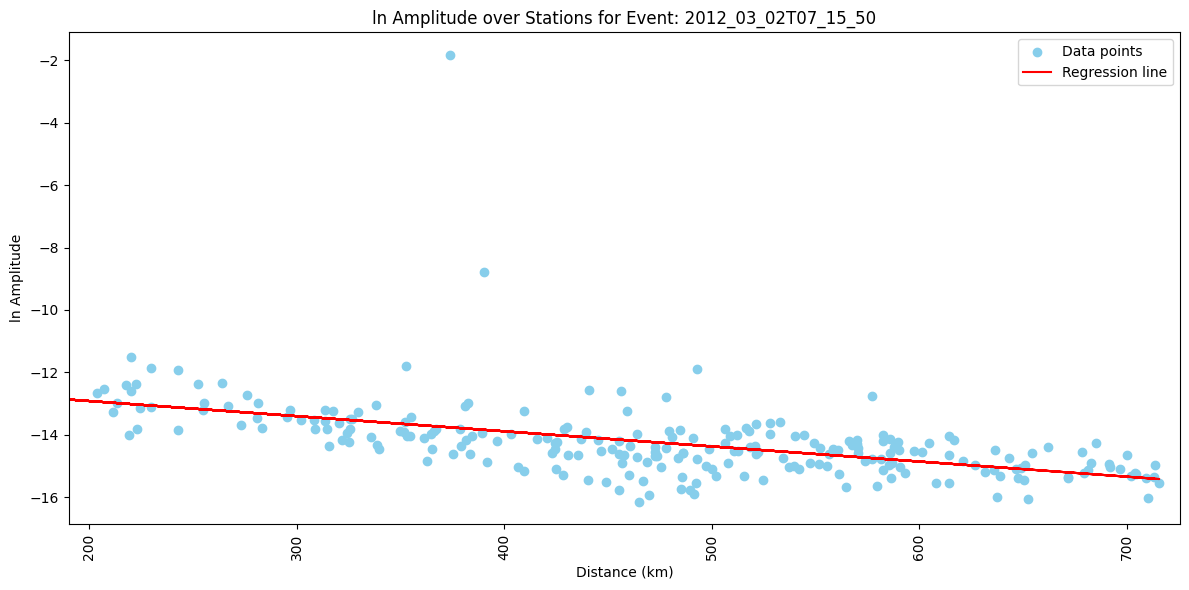

In [106]:
from scipy.stats import linregress
#event_time =  '2023_06_16T16_38_28'#  '2022_11_09T06_07_26'

event_time = list(results.keys())[44] 
event_data = results[event_time]

stations = list(event_data.keys())
log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
distances = [station_data["distance_km"] for station_data in event_data.values()]

filtered_distances = [d for d in distances if d > 200]
filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")
Q = -(np.pi*((fmin_value+fmax_value)/2)/(3.2*slope) )
print(f'for event {event_time} the Q factor is {Q}')
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
plt.plot(distances, intercept + slope * np.array(distances), color='red', label='Regression line')
plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190,max(filtered_distances)+10])
plt.title(f'ln Amplitude over Stations for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Processing complete.
Processed 168 events with Q0 and Sk values.


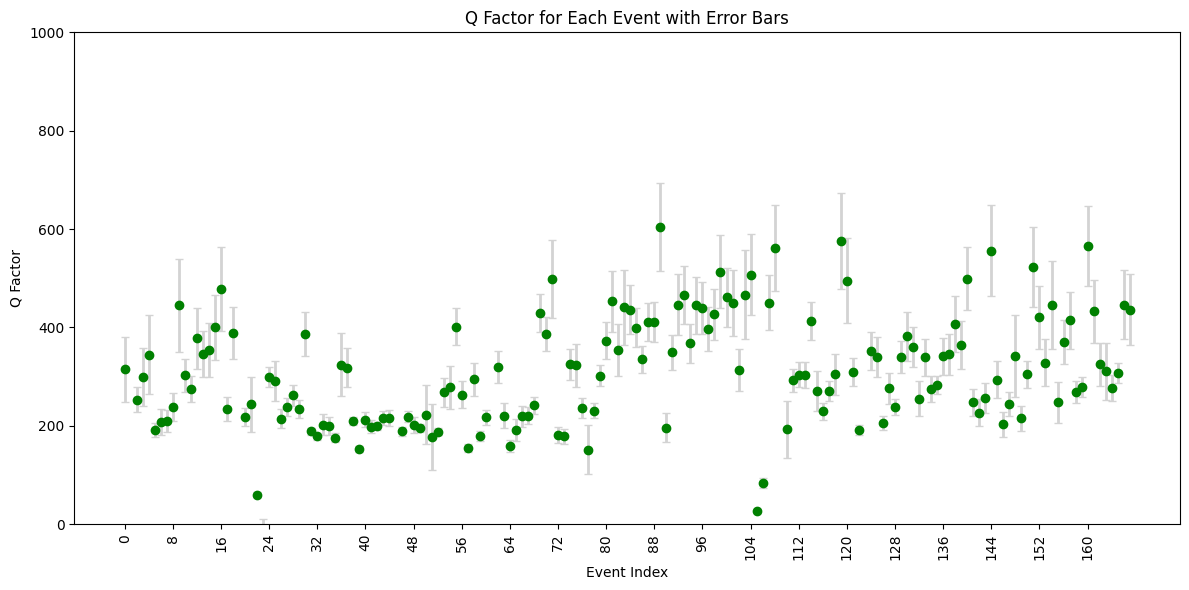

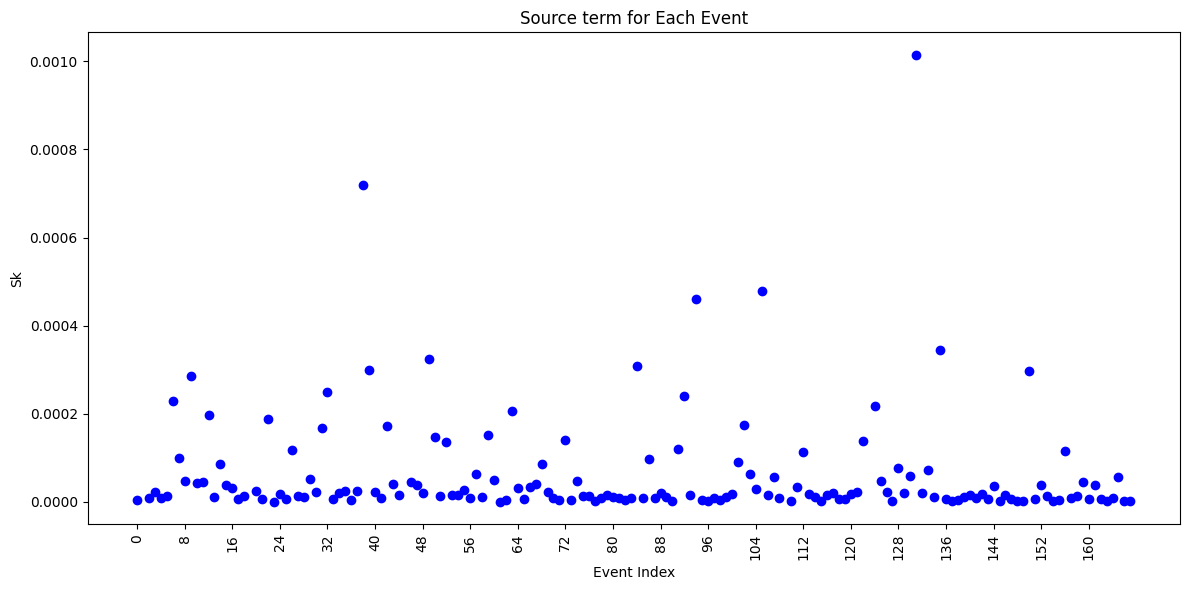

lower boundary 160.52341075576996 and upper boundary 499.1761370008423
163 events on map


In [107]:
def Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False, plot_Sk_map=False,special_site_terms=None,std_thresh=None):
    '''
    Input:
        - fmin: float, the minimum frequency
        - fmax: float, the maximum frequency
        - plot options: bool, if True, the plot will be shown
        - special_site_terms: dict, if you want to use a special site term, you can pass it here.
             In case the site term wants to be altered instead of read from disk.
        - std_thresh: float, if you want to set a threshold for the standard deviation of Q0, you can pass it here.

    Output:
        - dict with the Q0 and Sk values for all events for a single frequency range

    Method:
        - calculates, using Lg_amplitude_dict all the amplitudes of all stations for all events and frequency ranges
        - then for each event, the points of all available stations are 'plotted' against the distance
        - a linear regression is calculated, and the Q factor is calculated using the slope of the regression line, and Sk is calculated using the intercept
        - the error on Q0 and Sk is calculated using the standard error of the slope and intercept
        - if the option std_thresh is not None, events with a std higher than given threshold are not used in the above calculation
        - the results are stored in a dict, where the keys are the event times and the values are dicts with Q0, Sk and their errors
    '''





    base_directory = "/home/schreinl/Stage/Data1" 
    
    fminlist = [0.5,2,4,6]
    fmaxlist = [1.5,3,6,8]
    Lg_dict = Lg_amplitude_dict(base_directory,fminlist,fmaxlist)
    results, results_with_coords = Lg_amplitude_calculation(fmin, fmax, Lg_dict, savefile=False,special_site_terms=special_site_terms)

    event_data_dict = {}

    for event_time, event_data in results.items():
        log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
        distances = [station_data["distance_km"] for station_data in event_data.values()]

        filtered_distances = [d for d in distances if d > 200]
        filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]
        


        if len(filtered_distances) > 1:
            slope, intercept, r_value, p_value, std_err_slope = linregress(filtered_distances, filtered_log_amplitudes)


            #propagate the errors, maybe for further use
            f_avg = (fmin + fmax) / 2
            Q0 = - (np.pi * f_avg) / (3.2 * slope)
            Q0_error = np.abs((np.pi * f_avg) / (3.2 * slope**2)) * std_err_slope


            std_err_intercept = std_err_slope * np.sqrt(np.mean(np.square(filtered_distances))) 
            Sk = np.exp(intercept)
            Sk_error = Sk * std_err_intercept

            if std_thresh is not None:
                if Q0_error > std_thresh:
                    continue
                else:
                    if event_time in results_with_coords:
                        coordinates = results_with_coords[event_time]["coordinates"]
                        event_data_dict[event_time] = {
                            "Q0": Q0,
                            "Q0_error": Q0_error,
                            "Sk": Sk,
                            "Sk_error": Sk_error,
                            "coordinates": coordinates
                        }
            else:
                if event_time in results_with_coords:
                        coordinates = results_with_coords[event_time]["coordinates"]
                        event_data_dict[event_time] = {
                            "Q0": Q0,
                            "Q0_error": Q0_error,
                            "Sk": Sk,
                            "Sk_error": Sk_error,
                            "coordinates": coordinates
                        }




        

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")

    if plot_Q0 and event_data_dict:
        Q0_values = [data["Q0"] for data in event_data_dict.values()]
        Q0_errors = [data["Q0_error"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.errorbar(range(len(Q0_values)), Q0_values, yerr=Q0_errors, fmt='o', color='green', ecolor='lightgray', elinewidth=2, capsize=3)
        plt.xlabel('Event Index')
        plt.ylim([0, 1000])
        plt.ylabel('Q Factor')
        plt.title('Q Factor for Each Event with Error Bars')
        plt.xticks(range(0, len(Q0_values), max(1, len(Q0_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Sk and event_data_dict:
        Sk_values = [data["Sk"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Sk_values)), Sk_values, marker='o', color='blue')
        plt.xlabel('Event Index')
        plt.ylabel('Sk')
        plt.title('Source term for Each Event')
        plt.xticks(range(0, len(Sk_values), max(1, len(Sk_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Q0_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Q_values = [event_data["Q0"] for event_data in event_data_dict.values()]

        unique_Q_values = sorted(set(Q for Q in Q_values if not np.isnan(Q)))
        print(f'lower boundary {np.percentile(unique_Q_values,5)} and upper boundary {np.percentile(unique_Q_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Q_values,5), 
            vmax=np.percentile(unique_Q_values,95)
        )
        colormap.caption = "Q Factor"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Q = event_data["Q0"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Q):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Q:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Q),  # Use colormap with sorted values
                    weight=1,
                    fill=True,
                    fill_color=colormap(Q),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map
        

    if plot_Sk_map and event_data_dict:
        latitudes = [event_data['coordinates']["latitude"] for event_data in event_data_dict.values()]
        longitudes = [event_data['coordinates']["longitude"] for event_data in event_data_dict.values()]
        Sk_values = [event_data["Sk"] for event_data in event_data_dict.values()]

        unique_Sk_values = sorted(set(Sk for Sk in Sk_values if np.isfinite(Sk)))
        print(unique_Sk_values)
        print(f'lower boundary {np.percentile(unique_Sk_values,5)} and upper boundary {np.percentile(unique_Sk_values,95)}')
        colormap = cm.LinearColormap(
            colors=["blue", "green", "yellow", "orange", "red"], 
            vmin=np.percentile(unique_Sk_values,5), 
            vmax=np.percentile(unique_Sk_values,95)
        )
        colormap.caption = "Source Term"

        event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

        counter = 0
        for event_time, event_data in event_data_dict.items():
            Sk = event_data["Sk"]
            lat = event_data['coordinates']["latitude"]
            lon = event_data['coordinates']["longitude"]
            
            if not np.isnan(Sk):
                counter += 1
                popup_text = f"Event: {event_time}<br>Q: {Sk:.2f}"
                folium.CircleMarker(
                    location=[lat, lon],
                    radius=8,
                    tooltip=popup_text,
                    color=colormap(Sk),
                    weight=1,
                    fill=True,
                    fill_color=colormap(Sk),
                    fill_opacity=0.9
                ).add_to(event_map)

        colormap.add_to(event_map)
        print(f'{counter} events on map')
        event_map
        return event_data_dict, event_map



    return event_data_dict

Q0_Sk_dict, Q0_map = Lg_Q0_Sk(0.5, 1.5, plot_Q0=True, plot_Sk=True,plot_Q0_map=True,std_thresh=100)
Q0_map


frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 168 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 157 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 113 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processed 53 events with Q0 and Sk values.
Coefficients: a = 318.9777739307405, b = 0.40025784765700434


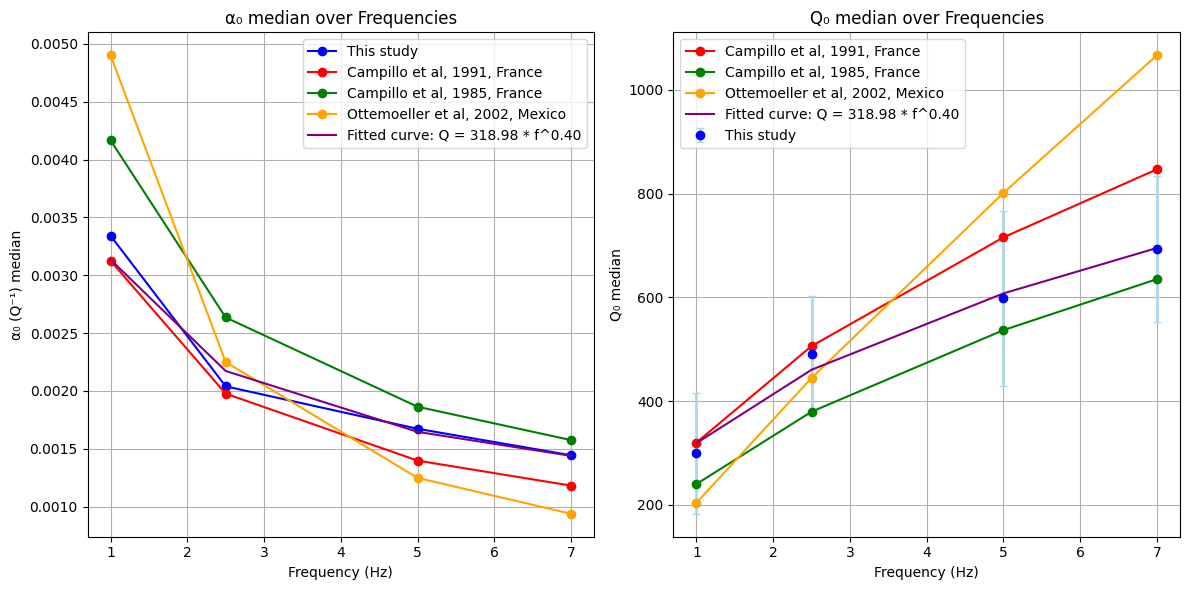

In [108]:
from scipy.optimize import curve_fit

def power_law(frequency, a, b):
    return a * frequency ** b

fmins = [0.5, 2, 4, 6]
fmaxs = [1.5, 3, 6, 8]
def Q_f(fmins,fmaxs,std_thresh=500):



    Q_mean = {}
    for mini, maxi in zip(fmins, fmaxs):
        fcenter = (mini + maxi) / 2
        print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
        Q0_Sk_dict = Lg_Q0_Sk(mini, maxi, plot_Q0=False, plot_Sk=False,std_thresh=100)
        Q0_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]
        Q_mean[f'{fcenter} Hz'] = {
            "Q_mean": np.nanmedian(Q0_values),
            "Q_std": np.nanstd(Q0_values)
        }

    frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
    Q_mean_values = [data["Q_mean"] for data in Q_mean.values()]
    Q_std_values = np.array([data["Q_std"] for data in Q_mean.values()])




    frequencies = np.array([float(freq.split()[0]) for freq in Q_mean.keys()])
    campillo_1991 = 320 * frequencies ** 0.5
    campillo_1985 = 240 * frequencies ** 0.5
    ottemoeller_2002 = 204* frequencies ** 0.85


    popt, pcov = curve_fit(power_law, frequencies, Q_mean_values, p0=[200, 0.5])

    a, b = popt
    print(f"Coefficients: a = {a}, b = {b}")

    fitted_Q = power_law(frequencies, a, b)
    plt.figure(figsize=(12, 6))

    # Plot α₀ (Q⁻¹) median
    plt.subplot(1, 2, 1)
    Q_mean_values = np.array(Q_mean_values)
    #plt.errorbar(frequencies, 1/Q_mean_values, yerr=1/Q_std_values, fmt='o', color='blue', ecolor='lightblue', elinewidth=2, capsize=3, label='This study')
    plt.plot(frequencies, 1 / Q_mean_values, marker='o', linestyle='-', color='blue', label='This study')
    plt.plot(frequencies, 1 / campillo_1991, marker='o', linestyle='-', color='red', label='Campillo et al, 1991, France')
    plt.plot(frequencies, 1 / campillo_1985, marker='o', linestyle='-', color='green', label='Campillo et al, 1985, France')
    plt.plot(frequencies, 1 / ottemoeller_2002, marker='o', linestyle='-', color='orange', label='Ottemoeller et al, 2002, Mexico')
    plt.plot(frequencies, 1 / fitted_Q, '-', label=f'Fitted curve: Q = {a:.2f} * f^{b:.2f}', color='purple')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('α₀ (Q⁻¹) median')
    plt.title('α₀ median over Frequencies')
    plt.grid(True)
    plt.legend()

    # Plot Q₀ median
    plt.subplot(1, 2, 2)
    plt.errorbar(frequencies, Q_mean_values, yerr=Q_std_values, fmt='o', color='blue', ecolor='lightblue', elinewidth=2, capsize=3, label='This study')
    plt.plot(frequencies, campillo_1991, marker='o', linestyle='-', color='red', label='Campillo et al, 1991, France')
    plt.plot(frequencies, campillo_1985, marker='o', linestyle='-', color='green', label='Campillo et al, 1985, France')
    plt.plot(frequencies, ottemoeller_2002, marker='o', linestyle='-', color='orange', label='Ottemoeller et al, 2002, Mexico')
    plt.plot(frequencies, fitted_Q, '-', label=f'Fitted curve: Q = {a:.2f} * f^{b:.2f}', color='purple')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Q₀ median')
    plt.title('Q₀ median over Frequencies')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()



Q_f(fmins,fmaxs,std_thresh=100)

In [ ]:
def Lg_Q_kl(fmin, fmax, Lg_dict, savefile=False):
    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)
    
    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))
    
    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)
    
    Q0_Sk_dict = Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False, plot_Q0_map=False, std_thresh=100)
    Qkl_dict = {}
    v = 3.2  # Velocity of the Lg wave in km/s
    
    freq_range_key = f"{fmin}-{fmax}"  # Key for the desired frequency range
    
    for event_time, freq_data in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        Qkl_dict[formatted_event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "frequencies": {}
        }
        
        if freq_range_key not in freq_data:
            continue
        
        Qkl_dict[formatted_event_time]["frequencies"][freq_range_key] = {"stations": {}}
        stations = freq_data[freq_range_key]
        
        for station, amplitude in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)
            
            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(float, freq_band.replace("Hz", "").split("_"))
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break
            
            if site_effect is None or site_effect <= 0 or r == 0:
                continue
            
            f = (fmin + fmax) / 2 

            source_term = Q0_Sk_dict[formatted_event_time]['frequencies'][freq_range_key]['Sk']
            Qkl = (-(np.pi * r * f) / v) * (-np.log(site_effect) - np.log(source_term) + np.log(amplitude * r**0.83))**-1
            
            Qkl_dict[formatted_event_time]["frequencies"][freq_range_key]["stations"][station] = {
                "Qkl": Qkl,
                "coordinates": {"latitude": lat, "longitude": lon}
            }
    
    if savefile:
        with open("../Data1/Qkl_results.json", "w") as f:
            json.dump(Qkl_dict, f, indent=4)
    
    return Qkl_dict

test_Qkl = Lg_Q_kl(0.5, 1.5, Lg_dict)

Processing complete.
Processed 168 events with Q0 and Sk values.


#### Testing the impact of site term on attenuation Q (already done above, here again for correct frequency handling)

Here we isolate once the influence of the site term, once we introduce an artifical (systematical error) on the site term, and once we use the site term as we have calculated it. Subsequently we can also see how we increase or decrease the quality of the Q measurements, when we only use stations that have more measures for their site effect than a specific threshold. The que


In [65]:
def Q_site_effect_sensitivity(fmin, fmax, Lg_dict, site_term_bias=0.0):
    '''
    Evaluate the sensitivity of the Q estimation to variations in site terms.

    Inputs:
        - fmin, fmax: float, frequency band to analyze
        - Lg_dict: dict from `Lg_amplitude_dict`, nested by [event][station][frequency_band]
        - site_term_bias: float, optional bias to add to the site term (e.g., for testing impact)

    Outputs:
        - results_real: dict, using true site terms
        - results_biased: dict, using biased site terms
        - results_no_site_term: dict, with no site terms
    '''
    import numpy as np
    import json, csv
    from obspy import UTCDateTime

    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)

    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results_real = {}
    results_biased = {}
    results_no_site_term = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue

        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        if formatted_event_time not in event_data:
            continue

        event_lat, event_lon = event_data[formatted_event_time]
        event_results_real = {}
        event_results_biased = {}
        event_results_no_site_term = {}

        for station, freq_data in stations.items():
            if station not in station_coords:
                continue

            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            for freq_range, amplitude in freq_data.items():
                freq_min_band, freq_max_band = map(float, freq_range.replace("Hz", "").split("_"))
                if not (fmin <= freq_min_band and fmax >= freq_max_band):
                    continue

                site_effect = None
                for site_freq_band, site_info in site_terms.items():
                    site_freq_min, site_freq_max = map(lambda x: float(x.replace('Hz', '').strip()), site_freq_band.split('-'))
                    if freq_min_band <= site_freq_min <= freq_max_band and freq_max_band >= site_freq_max >= freq_min_band:
                        if station.split(".")[1] in site_info:
                            site_effect = site_info[station.split(".")[1]].get("median_after", None)
                            break

                if site_effect is None or site_effect <= 0:
                    continue

                # Real site term
                log_value_real = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(site_effect)
                event_results_real[station] = {"log_value": log_value_real, "distance_km": r}

                # Biased site term
                biased_site_effect = site_effect + site_term_bias
                log_value_biased = np.log(amplitude) + (5 / 6) * np.log(r) - np.log(biased_site_effect)
                event_results_biased[station] = {"log_value": log_value_biased, "distance_km": r}

                # No site term
                log_value_no_site_term = np.log(amplitude) + (5 / 6) * np.log(r)
                event_results_no_site_term[station] = {"log_value": log_value_no_site_term, "distance_km": r}

        results_real[formatted_event_time] = event_results_real
        results_biased[formatted_event_time] = event_results_biased
        results_no_site_term[formatted_event_time] = event_results_no_site_term

    print("Processing complete.")
    return results_real, results_biased, results_no_site_term


results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(0.5, 1.5, Lg_dict, site_term_bias=0.1)


Processing complete.


Real values for event 2011_09_25T13_17_10:
Intercept: -11.855496522007352
Slope: -0.002093573544445719
Q factor: 468.9339463862644
Biased values for event 2011_09_25T13_17_10:
Intercept: -11.93000069371545
Slope: -0.0021374365350854117
Q factor: 459.31080906108855
No site term values for event 2011_09_25T13_17_10:
Intercept: -11.232714327862258
Slope: -0.002877987826616928
Q factor: 341.1229523513495


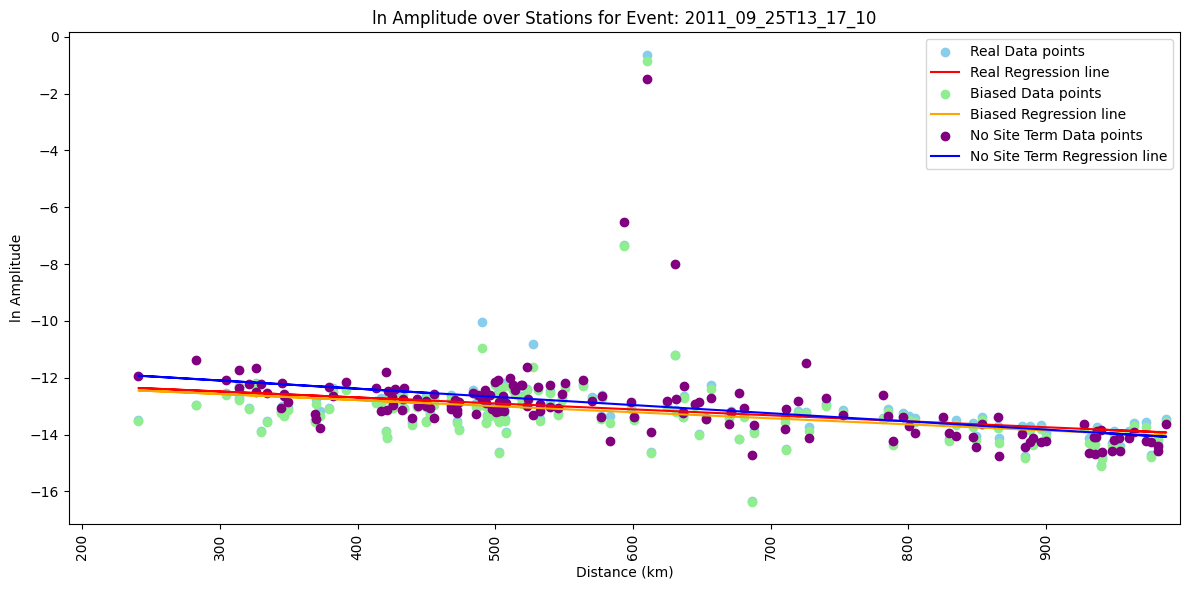

In [69]:
event_time = list(results_real.keys())[40] 
event_data_real = results_real[event_time]
event_data_biased = results_biased[event_time]
event_data_no_site_term = results_no_site_term[event_time]
fminval = 0.5
fmaxval=1.5
# Real values
stations_real = list(event_data_real.keys())
log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]

filtered_distances_real = [d for d in distances_real if d > 200]
filtered_log_amplitudes_real = [log_amplitudes_real[i] for i in range(len(distances_real)) if distances_real[i] > 200]

slope_real, intercept_real, _, _, _ = linregress(filtered_distances_real, filtered_log_amplitudes_real)

Q_real = -(np.pi * ((fminval + fmaxval) / 2) / (3.2 * slope_real))
print(f"Real values for event {event_time}:")
print(f"Intercept: {intercept_real}")
print(f"Slope: {slope_real}")
print(f"Q factor: {Q_real}")

# Biased values
stations_biased = list(event_data_biased.keys())
log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]

filtered_distances_biased = [d for d in distances_biased if d > 200]
filtered_log_amplitudes_biased = [log_amplitudes_biased[i] for i in range(len(distances_biased)) if distances_biased[i] > 200]

slope_biased, intercept_biased, _, _, _ = linregress(filtered_distances_biased, filtered_log_amplitudes_biased)

Q_biased = -(np.pi * ((fminval + fmaxval) / 2) / (3.2 * slope_biased))
print(f"Biased values for event {event_time}:")
print(f"Intercept: {intercept_biased}")
print(f"Slope: {slope_biased}")
print(f"Q factor: {Q_biased}")

# No site term values
stations_no_site_term = list(event_data_no_site_term.keys())
log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]

filtered_distances_no_site_term = [d for d in distances_no_site_term if d > 200]
filtered_log_amplitudes_no_site_term = [log_amplitudes_no_site_term[i] for i in range(len(distances_no_site_term)) if distances_no_site_term[i] > 200]

slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)

Q_no_site_term = -(np.pi * ((fminval + fmaxval) / 2) / (3.2 * slope_no_site_term))
print(f"No site term values for event {event_time}:")
print(f"Intercept: {intercept_no_site_term}")
print(f"Slope: {slope_no_site_term}")
print(f"Q factor: {Q_no_site_term}")

# Combined plot
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances_real, filtered_log_amplitudes_real, color='skyblue', label='Real Data points')
plt.plot(filtered_distances_real, intercept_real + slope_real * np.array(filtered_distances_real), color='red', label='Real Regression line')

plt.scatter(filtered_distances_biased, filtered_log_amplitudes_biased, color='lightgreen', label='Biased Data points')
plt.plot(filtered_distances_biased, intercept_biased + slope_biased * np.array(filtered_distances_biased), color='orange', label='Biased Regression line')

plt.scatter(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term, color='purple', label='No Site Term Data points')
plt.plot(filtered_distances_no_site_term, intercept_no_site_term + slope_no_site_term * np.array(filtered_distances_no_site_term), color='blue', label='No Site Term Regression line')

plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190, max(max(filtered_distances_real), max(filtered_distances_biased), max(filtered_distances_no_site_term)) + 10])
plt.title(f'ln Amplitude over Stations for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Processing complete.
Processed 203 events with Q0 and Sk values.


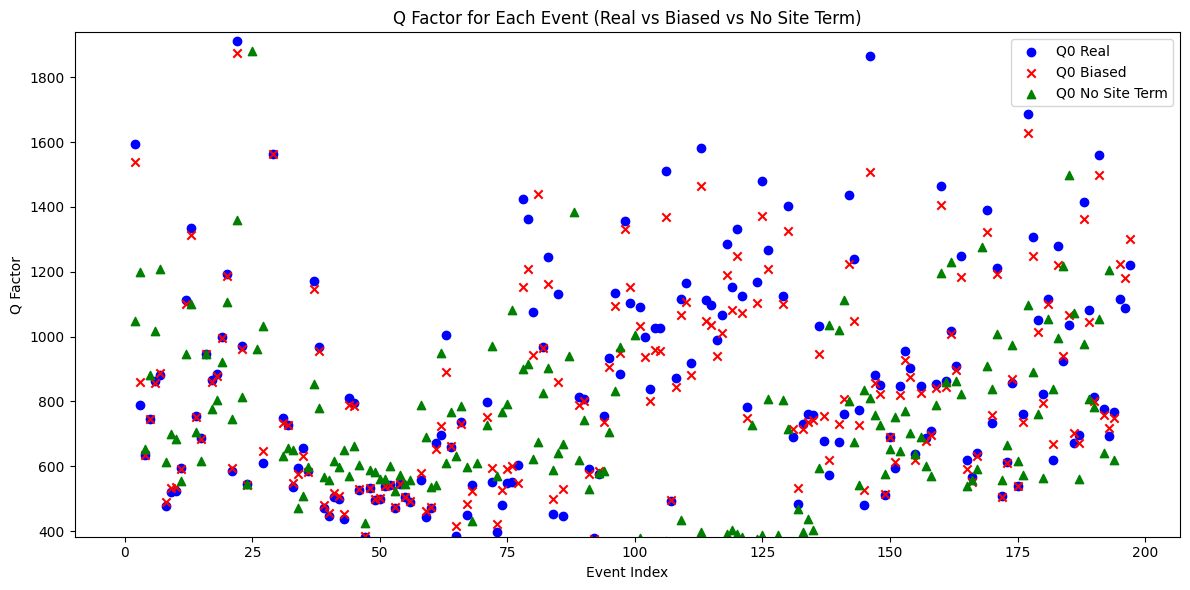

In [80]:
def Lg_Q0_Sk_biased(fmin, fmax, site_term_bias=0.1, plot_Q0=False, plot_Sk=False):
    fminlist = [0.5, 2, 4, 6]  
    fmaxlist = [1.5,3, 6, 8] 

    base_directory = "/home/schreinl/Stage/Data1"
    Lg_dict = Lg_amplitude_dict(base_directory, fminlist, fmaxlist)
    results_real, results_biased, results_no_site_term = Q_site_effect_sensitivity(0.5, 1.5, Lg_dict, site_term_bias=0.1)
    event_data_dict = {}
    square_vals = {"Q0 real - Q0 bias": {},"Q0 real - Q0 no site term": {}, "Sk real - Sk bias": {}, "Sk real - Sk no site term": {}}
    l2_norms = {}

    for event_time, event_data_real in results_real.items():
        event_data_biased = results_biased.get(event_time, {})
        event_data_no_site_term = results_no_site_term.get(event_time, {})
        
        # Extract real data
        log_amplitudes_real = [station_data["log_value"] for station_data in event_data_real.values()]
        distances_real = [station_data["distance_km"] for station_data in event_data_real.values()]
        filtered_distances_real = [d for d in distances_real if d > 200]
        filtered_log_amplitudes_real = [log_amplitudes_real[i] for i in range(len(distances_real)) if distances_real[i] > 200]

        # Extract biased data
        log_amplitudes_biased = [station_data["log_value"] for station_data in event_data_biased.values()]
        distances_biased = [station_data["distance_km"] for station_data in event_data_biased.values()]
        filtered_distances_biased = [d for d in distances_biased if d > 200]
        filtered_log_amplitudes_biased = [log_amplitudes_biased[i] for i in range(len(distances_biased)) if distances_biased[i] > 200]

        # Extract no site term data
        log_amplitudes_no_site_term = [station_data["log_value"] for station_data in event_data_no_site_term.values()]
        distances_no_site_term = [station_data["distance_km"] for station_data in event_data_no_site_term.values()]
        filtered_distances_no_site_term = [d for d in distances_no_site_term if d > 200]
        filtered_log_amplitudes_no_site_term = [log_amplitudes_no_site_term[i] for i in range(len(distances_no_site_term)) if distances_no_site_term[i] > 200]

        if len(filtered_distances_real) > 1 and len(filtered_distances_biased) > 1 and len(filtered_distances_no_site_term) > 1:
            # Real data regression
            slope_real, intercept_real, _, _, _ = linregress(filtered_distances_real, filtered_log_amplitudes_real)
            if isinstance(slope_real, (int, float)) and slope_real != 0:
                Q_real = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_real))
                Sk_real = np.exp(intercept_real)
            else:
                Q_real = None
                Sk_real = None

            # Biased data regression
            if len(filtered_distances_biased) > 1:
                slope_biased, intercept_biased, _, _, _ = linregress(filtered_distances_biased, filtered_log_amplitudes_biased)
                if isinstance(slope_biased, (int, float)) and slope_biased != 0:
                    Q_biased = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_biased))
                    Sk_biased = np.exp(intercept_biased)
                else:
                    Q_biased = None
                    Sk_biased = None
            else:
                Q_biased = None
                Sk_biased = None

            # No site term data regression
            slope_no_site_term, intercept_no_site_term, _, _, _ = linregress(filtered_distances_no_site_term, filtered_log_amplitudes_no_site_term)
            Q_no_site_term = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope_no_site_term))
            Sk_no_site_term = np.exp(intercept_no_site_term)

            if event_time in results_with_coords:
                coordinates = results_with_coords[event_time]["coordinates"]
                event_data_dict[event_time] = {
                    "Q0_real": Q_real,
                    "Sk_real": Sk_real,
                    "Q0_biased": Q_biased,
                    "Sk_biased": Sk_biased,
                    "Q0_no_site_term": Q_no_site_term,
                    "Sk_no_site_term": Sk_no_site_term,
                    "coordinates": coordinates
                }

                if Q_real is not None and Q_biased is not None:
                    square_vals["Q0 real - Q0 bias"][event_time] = (Q_real - Q_biased) ** 2
                    
                if Q_real is not None and Q_no_site_term is not None:
                    square_vals["Q0 real - Q0 no site term"][event_time] = (Q_real - Q_no_site_term) ** 2 
                    
                if Sk_real is not None and Sk_biased is not None:
                    square_vals["Sk real - Sk bias"][event_time] = (Sk_real - Sk_biased) ** 2
                    
                if Sk_real is not None and Sk_no_site_term is not None:
                    square_vals["Sk real - Sk no site term"][event_time] = (Sk_real - Sk_no_site_term) ** 2 
                    

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")
    for norm_key, norm_values in l2_norms.items():
        valid_norms = [v for v in norm_values.values() if np.isfinite(v)]
        if valid_norms:
            print(f"L2 Norms for {norm_key}: {valid_norms}")
        else:
            print(f"L2 Norms for {norm_key}: No valid values.")
    
    for key, values in square_vals.items():
        valid_values = [v for v in values.values() if np.isfinite(v)]
        if valid_values:
            l2_norms[key] = np.sqrt(np.sum(valid_values))
        else:
            l2_norms[key] = None



    if plot_Q0 and event_data_dict:
        Q0_real_values = [data["Q0_real"] for data in event_data_dict.values() if np.isfinite(data["Q0_real"])]
        Q0_biased_values = [data["Q0_biased"] for data in event_data_dict.values() if np.isfinite(data["Q0_biased"])]
        Q0_no_site_term_values = [data["Q0_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Q0_no_site_term"])]
        
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Q0_real_values)), Q0_real_values, marker='o', color='blue', label='Q0 Real')
            plt.scatter(range(len(Q0_biased_values)), Q0_biased_values, marker='x', color='red', label='Q0 Biased')
            plt.scatter(range(len(Q0_no_site_term_values)), Q0_no_site_term_values, marker='^', color='green', label='Q0 No Site Term')
            plt.xlabel('Event Index')
            #plt.xlim([40,50])
            plt.ylim([np.percentile(Q0_real_values, 5), np.percentile(Q0_real_values, 95)])
            plt.ylabel('Q Factor')
            plt.title('Q Factor for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

    if plot_Sk and event_data_dict:
        Sk_real_values = [data["Sk_real"] for data in event_data_dict.values() if np.isfinite(data["Sk_real"])]
        Sk_biased_values = [data["Sk_biased"] for data in event_data_dict.values() if np.isfinite(data["Sk_biased"])]
        Sk_no_site_term_values = [data["Sk_no_site_term"] for data in event_data_dict.values() if np.isfinite(data["Sk_no_site_term"])]
        if Q0_real_values:
            plt.figure(figsize=(12, 6))
            plt.scatter(range(len(Sk_real_values)), Sk_real_values, marker='o', color='blue', label='Sk Real')
            plt.scatter(range(len(Sk_biased_values)), Sk_biased_values, marker='x', color='red', label='Sk Biased')
            plt.scatter(range(len(Sk_no_site_term_values)), Sk_no_site_term_values, marker='^', color='green', label='Sk No Site Term')
            plt.xlabel('Event Index')
            plt.ylim([np.percentile(Sk_real_values, 5), np.percentile(Sk_real_values, 95)])
            plt.ylabel('Source Term (Sk)')
            plt.title('Source Term for Each Event (Real vs Biased vs No Site Term)')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No valid Q0 values to plot.")

        q0_real_q0_biased_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 bias"].values() if np.isfinite(v)]
        average_diff_real_biased = np.mean(q0_real_q0_biased_diffs) if q0_real_q0_biased_diffs else None

        q0_real_q0_no_site_term_diffs = [np.sqrt(v) for v in square_vals["Q0 real - Q0 no site term"].values() if np.isfinite(v)]
        average_diff_real_no_site_term = np.mean(q0_real_q0_no_site_term_diffs) if q0_real_q0_no_site_term_diffs else None

        print(f"Average difference between Q0 real and Q0 biased: {average_diff_real_biased}")
        print(f"Average difference between Q0 real and Q0 no site term: {average_diff_real_no_site_term}")


    return event_data_dict, l2_norms


biased_dict, l2_norms = Lg_Q0_Sk_biased(2, 3, site_term_bias=5, plot_Q0=True, plot_Sk=False)

frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 203 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 203 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 203 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processed 203 events with Q0 and Sk values.


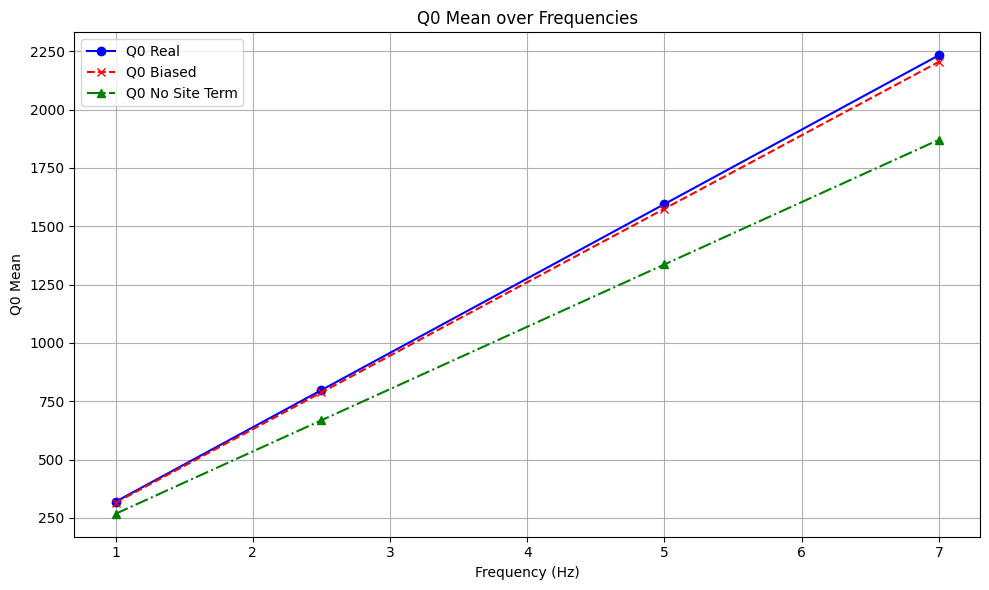

In [88]:
fmins = [0.5, 2, 4,6]
fmaxs = [1.5, 3, 6, 8]
Q_mean = {}
for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    biased_dict, l2_norms = Lg_Q0_Sk_biased(mini, maxi, site_term_bias=5, plot_Q0=False, plot_Sk=False)
    Q0_real_values = [data["Q0_real"] for data in biased_dict.values() if np.isfinite(data["Q0_real"])]
    Q0_biased_values = [data["Q0_biased"] for data in biased_dict.values() if np.isfinite(data["Q0_biased"])]
    Q0_no_site_term_values = [data["Q0_no_site_term"] for data in biased_dict.values() if np.isfinite(data["Q0_no_site_term"])]
    Q_mean[f'{fcenter} Hz'] = {"Q0_real": np.nanmedian(Q0_real_values), "Q0_biased": np.nanmedian(Q0_biased_values), "Q0_no_ite_term": np.nanmedian(Q0_no_site_term_values)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q0_real"] for data in Q_mean.values()]




frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q0_real_values = [data["Q0_real"] for data in Q_mean.values()]
Q0_biased_values = [data["Q0_biased"] for data in Q_mean.values()]
Q0_no_site_term_values = [data["Q0_no_ite_term"] for data in Q_mean.values()]

plt.figure(figsize=(10, 6))
plt.plot(frequencies, Q0_real_values, marker='o', linestyle='-', color='blue', label='Q0 Real')
plt.plot(frequencies, Q0_biased_values, marker='x', linestyle='--', color='red', label='Q0 Biased')
plt.plot(frequencies, Q0_no_site_term_values, marker='^', linestyle='-.', color='green', label='Q0 No Site Term')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q0 Mean')
plt.title('Q0 Mean over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Faire tout la manip qu'avec des stations qui ont site mesures avec plus que 3 points 

In [97]:
fmin = 0.5
fmax = 1.5
frequenciesmin = [0.5,2,4,6]
frequenciesmax = [1.5,3,6,8]
event_file='/home/schreinl/Stage/Data/big_box_4.5.csv'
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

dict_test = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", factor=1.1, fmin=fmin, fmax=fmax, data_dir='Data1',envelope_name='new')
ref_value_test = reference_stations_median(best_bet,event_file, fmin, fmax, envelope_name='new')
sites_effect_dict_test = site_effect_dict(event_file, fmin,fmax,best_bet,envelope_name='new')

site_effects = site_effect_overall(fmin,fmax,best_bet,frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax,method='multiple',map_plot=False,envelope_name='new')

filtered_site_effects = {}
for freq_band, stations in site_effects.items():
    filtered_site_effects[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 1
    }

carte = map_site_effect(fmin, fmax, filtered_site_effects, method='multiple')
#carte.save(f"site_effect_{(fmin+fmax)/2}_Hz_map.html")
carte



#def Q_filtered_site_term():
    

done reading in


frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processed 203 events with Q0 and Sk values.
Processing complete.
Processed 202 events with Q0 and Sk values.
Processing complete.
Processed 203 events with Q0 and Sk values.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processed 209 events with Q0 and Sk values.
Processing complete.
Processed 209 events with Q0 and Sk values.
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processed 209 events with Q0 and Sk values.
Processing complete.
Processed 208 events with Q0 and Sk values.
Processing complete.
Processed 209 events with Q0 and Sk values.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processed 208 events with Q0 and Sk values.
Processing complete.
Processed 208 events with Q0 and Sk values.
Processing complete.
Processed 208 events with Q0 and Sk values.


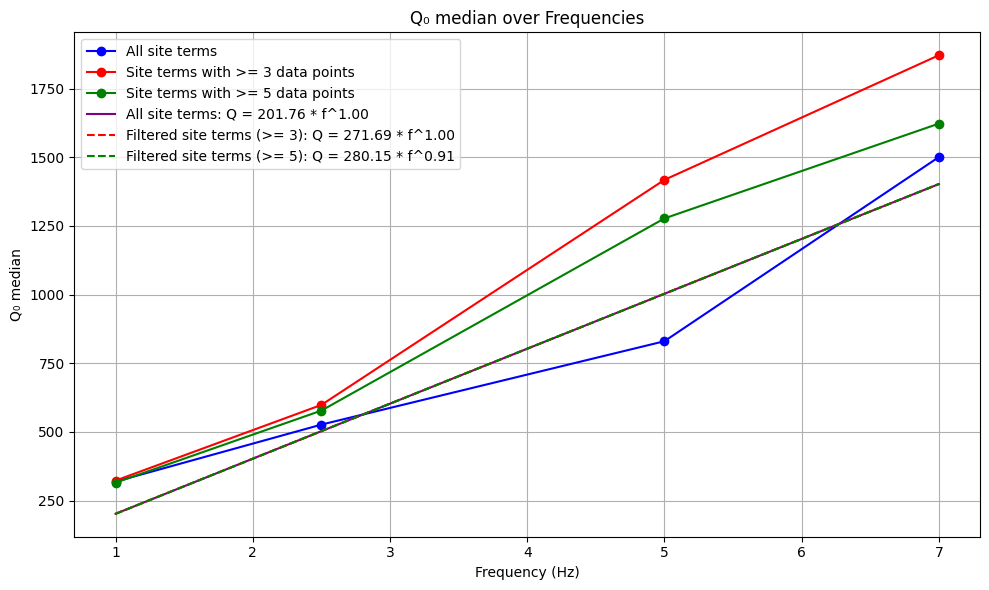

In [100]:
fmin = [0.5, 2, 4, 6]  
fmax = [1.5, 3, 6, 8] 

base_directory = "/home/schreinl/Stage/Data1" 

filtered_site_effects_3 = {}
filtered_site_effects_5 = {}

for freq_band, stations in site_effects.items():
    filtered_site_effects_3[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 3
    }
    filtered_site_effects_5[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 5
    }

# Q values filtered for site terms with >= 3 and >= 5 data points
fmins = [0.5, 2, 4, 6]
fmaxs = [1.5, 3, 6, 8]
Q_mean = {}
Q_mean_filt_3 = {}
Q_mean_filt_5 = {}


for mini, maxi in zip(fmins, fmaxs):
    fcenter = (mini + maxi) / 2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    
    Q0_Sk_dict_filt_3 = Lg_Q0_Sk(mini, maxi, special_site_terms=filtered_site_effects_3, plot_Q0=False, plot_Sk=False)
    Q0_Sk_dict_filt_5 = Lg_Q0_Sk(mini, maxi, special_site_terms=filtered_site_effects_5, plot_Q0=False, plot_Sk=False)
    Q0_Sk_dict = Lg_Q0_Sk(mini, maxi, special_site_terms=None, plot_Q0=False, plot_Sk=False)
    
    Q0_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]
    Q0_values_filt_3 = [event_data["Q0"] for event_data in Q0_Sk_dict_filt_3.values()]
    Q0_values_filt_5 = [event_data["Q0"] for event_data in Q0_Sk_dict_filt_5.values()]
    
    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values), "std": np.nanstd(Q0_values)}
    Q_mean_filt_3[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values_filt_3), "std": np.nanstd(Q0_values_filt_3)}
    Q_mean_filt_5[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(Q0_values_filt_5), "std": np.nanstd(Q0_values_filt_5)}

frequencies = [float(freq.split()[0]) for freq in Q_mean.keys()]
Q_mean_values = [data["Q_mean"] for data in Q_mean.values()]
Q_mean_values_filt_3 = [data["Q_mean"] for data in Q_mean_filt_3.values()]
Q_mean_values_filt_5 = [data["Q_mean"] for data in Q_mean_filt_5.values()]

popt, pcov = curve_fit(power_law, frequencies, Q_mean_values)
popt_filt_3, pcov_filt_3 = curve_fit(power_law, frequencies, Q_mean_values_filt_3)
popt_filt_5, pcov_filt_5 = curve_fit(power_law, frequencies, Q_mean_values_filt_5)

a, b = popt
a_filt_3, b_filt_3 = popt_filt_3
a_filt_5, b_filt_5 = popt_filt_5

fitted_Q = power_law(frequencies, a, b)

plt.figure(figsize=(10, 6))

Q_mean_values = np.array(Q_mean_values) 
Q_mean_values_filt_3 = np.array(Q_mean_values_filt_3) 
Q_mean_values_filt_5 = np.array(Q_mean_values_filt_5) 

plt.plot(frequencies, Q_mean_values, marker='o', linestyle='-', color='blue', label='All site terms')
plt.plot(frequencies, Q_mean_values_filt_3, marker='o', linestyle='-', color='red', label='Site terms with >= 3 data points')
plt.plot(frequencies, Q_mean_values_filt_5, marker='o', linestyle='-', color='green', label='Site terms with >= 5 data points')
plt.plot(frequencies, fitted_Q, '-', label=f'All site terms: Q = {a:.2f} * f^{b:.2f}', color='purple')
plt.plot(frequencies, fitted_Q, '--', label=f'Filtered site terms (>= 3): Q = {a_filt_3:.2f} * f^{b_filt_3:.2f}', color='red')
plt.plot(frequencies, fitted_Q, '--', label=f'Filtered site terms (>= 5): Q = {a_filt_5:.2f} * f^{b_filt_5:.2f}', color='green')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Q₀ median')
plt.title('Q₀ median over Frequencies')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Spatially gridding Q

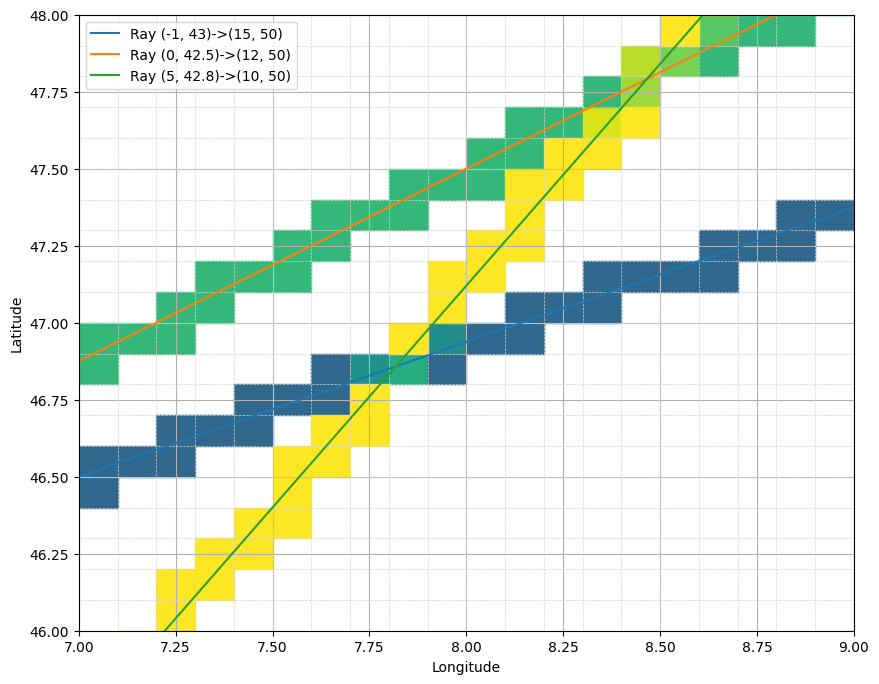

In [101]:
import numpy as np
from shapely.geometry import LineString, box
import matplotlib.pyplot as plt
from collections import defaultdict

def calculate_all_ray_paths(ray_paths, values, x_edges, y_edges):
    """
    Calculate the weighted average values for each grid cell traversed by ray paths.

    Parameters:
    - ray_paths: list of tuples, each containing (start_point, end_point).
    - values: list of floats, the value associated with each ray path.
    - x_edges: numpy array, grid x-edges.
    - y_edges: numpy array, grid y-edges.

    Returns:
    - cell_values: dict, keys are (i, j) grid indices, values are weighted averages.
    - all_ray_segments: list of tuples ((i, j), length) for plotting.
    """
    cell_contributions = defaultdict(lambda: {"total_length": 0, "weighted_sum": 0})
    all_ray_segments = []

    for (start_point, end_point), value in zip(ray_paths, values):
        line = LineString([start_point, end_point])
        for i in range(len(x_edges) - 1):
            for j in range(len(y_edges) - 1):
                cell = box(x_edges[i], y_edges[j], x_edges[i + 1], y_edges[j + 1])
                if line.intersects(cell):
                    intersection = line.intersection(cell)
                    length = intersection.length
                    if length > 0:
                        cell_contributions[(i, j)]["total_length"] += length
                        cell_contributions[(i, j)]["weighted_sum"] += value * length
                        all_ray_segments.append(((i, j), length))
                        
    cell_values = {}
    for (i, j), contrib in cell_contributions.items():
        total_length = contrib["total_length"]
        weighted_sum = contrib["weighted_sum"]
        cell_values[(i, j)] = weighted_sum / total_length if total_length > 0 else 0

    return cell_values, all_ray_segments




ray_paths = [
    ((-1, 43), (15, 50)),
    ((0, 42.5), (12, 50)),
    ((5, 42.8), (10, 50))
]
values = [10, 20, 30]  

x_edges = np.arange(-2, 16, 0.1)
y_edges = np.arange(42, 51, 0.1)

cell_values, all_ray_segments = calculate_all_ray_paths(ray_paths, values, x_edges, y_edges)

plt.figure(figsize=(10, 8))

for x_edge in x_edges:
    plt.plot([x_edge, x_edge], [y_edges[0], y_edges[-1]], color='lightgray', linestyle='--', linewidth=0.5)
for y_edge in y_edges:
    plt.plot([x_edges[0], x_edges[-1]], [y_edge, y_edge], color='lightgray', linestyle='--', linewidth=0.5)

for (start, end) in ray_paths:
    plt.plot([start[0], end[0]], [start[1], end[1]], label=f'Ray {start}->{end}')

for (i, j), value in cell_values.items():
    plt.gca().add_patch(
        plt.Rectangle(
            (x_edges[i], y_edges[j]),
            x_edges[i + 1] - x_edges[i],
            y_edges[j + 1] - y_edges[j],
            color=plt.cm.viridis(value / max(values)),
        )
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(7,9)
plt.ylim(46,48)
plt.legend()
plt.grid(True)
plt.show()


In [41]:


def plot_Qkl_map(Qkl_dict, fmin, fmax):
    Qkl_values = []
    for event in Qkl_dict.values():
        if 'stations' in event: 
            for station, station_data in event['stations'].items():
                Qkl = station_data.get('Qkl', None)
                if Qkl is not None and np.isfinite(Qkl):  # Filter out None and NaN values
                    Qkl_values.append(Qkl)

    if not Qkl_values:
        raise ValueError("No valid Qkl values found for plotting.")

    Qkl_values.sort()

    vmin = np.percentile(Qkl_values, 5)
    vmax = np.percentile(Qkl_values, 95)
    if vmin > vmax:
        vmin, vmax = sorted([vmin, vmax])

    colormap = LinearColormap(
        colors=["blue", "green", "yellow", "orange", "red"],
        vmin=vmin,
        vmax=vmax
    )

    latitudes = []
    longitudes = []
    
    


    for event in Qkl_dict.values():
        if 'coordinates' in event:
            event_lat = event['coordinates'].get('latitude')
            event_lon = event['coordinates'].get('longitude')
            if event_lat is not None and event_lon is not None:
                latitudes.append(event_lat)
                longitudes.append(event_lon)

        for station, station_data in event.get('stations', {}).items():
            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')
            if station_lat is not None and station_lon is not None:
                latitudes.append(station_lat)
                longitudes.append(station_lon)

    event_map = folium.Map(
        location=[np.mean(latitudes), np.mean(longitudes)],
        zoom_start=5,
        tiles="OpenStreetMap",
    )

    for event_time, event in Qkl_dict.items():
        if 'coordinates' not in event:
            continue
        event_lat = event['coordinates'].get('latitude')
        event_lon = event['coordinates'].get('longitude')

        if event_lat is None or event_lon is None:
            continue

        for station, station_data in event.get('stations', {}).items():
            Qkl = station_data.get('Qkl', None)
            if Qkl is None or not np.isfinite(Qkl):  # Skip invalid Qkl values
                continue

            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')

            folium.PolyLine(
                locations=[(event_lat, event_lon), (station_lat, station_lon)],
                color=colormap(Qkl), 
                weight=2,
                opacity=0.5,  # Set transparency
                tooltip=f"Event: {event_time}<br>Station: {station}<br>Qkl: {Qkl:.2f}"
            ).add_to(event_map)

    colormap.add_to(event_map)

    return event_map




Lg_Q_kl(0.5, 1.5, Lg_dict, savefile=False)
Qkl_map = plot_Qkl_map(test_Qkl, fmin=0.5, fmax=1.5)





TypeError: Lg_amplitude_dict() takes 1 positional argument but 3 were given

In [102]:
from shapely.geometry import LineString, box
from collections import defaultdict
from tqdm.auto import tqdm

def compute_weighted_Qkl_grid(Qkl_dict, x_edges, y_edges):
    cell_contributions = defaultdict(lambda: {"total_length": 0, "weighted_sum": 0})
    total_events = len(Qkl_dict)
    pbar = tqdm(total=total_events, desc="Processing events", unit="event")

    for event_data in Qkl_dict.values():
        event_coords = event_data["coordinates"]
        event_point = (event_coords["longitude"], event_coords["latitude"])

        for station_data in event_data["stations"].values():
            station_coords = station_data["coordinates"]
            Qkl = station_data["Qkl"]
            station_point = (station_coords["longitude"], station_coords["latitude"])

            line = LineString([event_point, station_point])

            for i in range(len(x_edges) - 1):
                for j in range(len(y_edges) - 1):
                    cell = box(x_edges[i], y_edges[j], x_edges[i+1], y_edges[j+1])
                    if line.intersects(cell):
                        intersection = line.intersection(cell)
                        length = intersection.length
                        if length > 0:
                            cell_contributions[(i, j)]["total_length"] += length
                            cell_contributions[(i, j)]["weighted_sum"] += Qkl * length

        pbar.update(1) 

    pbar.close()

    weighted_Qkl_grid = {
        cell: contrib["weighted_sum"] / contrib["total_length"]
        for cell, contrib in cell_contributions.items()
        if contrib["total_length"] > 0
    }

    return weighted_Qkl_grid



x_edges = np.arange(-2, 16, 1)
y_edges = np.arange(42, 51, 1)
Qkl_dict = test_Qkl
weighted_Qkl_grid = compute_weighted_Qkl_grid(Qkl_dict, x_edges, y_edges)
plot_weighted_Qkl_grid(weighted_Qkl_grid, x_edges, y_edges)


NameError: name 'test_Qkl' is not defined

In [119]:

def plot_weighted_Qkl_grid(weighted_Qkl_grid, x_edges, y_edges):
    values = list(weighted_Qkl_grid.values())
    vmax = max(values)

    plt.figure(figsize=(10, 8))
    for (i, j), Qkl_val in weighted_Qkl_grid.items():
        plt.gca().add_patch(
            plt.Rectangle(
                (x_edges[i], y_edges[j]),
                x_edges[i + 1] - x_edges[i],
                y_edges[j + 1] - y_edges[j],
                color=plt.cm.viridis(Qkl_val / vmax),
                alpha=0.7
            )
        )

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Grid Cells Weighted by Qkl')
    plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), label='Weighted Qkl')
    plt.grid(True)
    plt.show()


In [122]:
from tqdm.notebook import tqdm 

x_edges = np.arange(-2, 16, 1)
y_edges = np.arange(42, 51, 1)
Qkl_dict = test_Qkl
weighted_Qkl_grid = compute_weighted_Qkl_grid(Qkl_dict, x_edges, y_edges)
plot_weighted_Qkl_grid(weighted_Qkl_grid, x_edges, y_edges)

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html